# Network Slicing - Complete Analysis & Preparation

## 🎯 Objectif
Analyse complète et préparation du dataset network slicing v3 :
1. **Analyse exploratoire** des données brutes
2. **Détection** des valeurs manquantes/aberrantes
3. **Imputation** intelligente des valeurs manquantes
4. **Suppression** du biais (Use Case Type)
5. **Préparation** finale pour le Machine Learning

## 📁 Dataset
- **Source** : `network_slicing_dataset - v3_6G_OLD.csv`
- **Lignes** : 10 000
- **Colonnes** : 13 → 12 (après nettoyage)

## Part 1: Setup & Data Loading

In [29]:
## STEP 1 — Setup & Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("✅ Libraries imported successfully!")

# Load and convert dataset
df = pd.read_csv('network_slicing_dataset - v3_6G_OLD.csv', sep=';')

# Convert budget columns to numeric (handling comma decimal separator)
budget_columns = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)','Data R date Budget (Gbps)']
for col in budget_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")

✅ Libraries imported successfully!


FileNotFoundError: [Errno 2] No such file or directory: 'network_slicing_dataset - v3_6G_OLD.csv'

## STEP 2 — First Look at the Data

In [ ]:
# Display dataset shape and columns
print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

📊 Dataset shape: (10000, 13)
📋 Column names:
   1. Use Case Type
   2. Packet Loss Budget
   3. Latency Budget (ns)
   4. Jitter Budget (ns)
   5. Data R date Budget (Gbps)
   6. Required Mobility
   7. Required Connectivity
   8. Slice Available Transfer Rate (Gbps)
   9. Slice Latency (ns)
  10. Slice Packet Loss
  11. Slice Jitter (ns)
  12. Slice Type
  13. Slice Handover


## STEP 3 — Data Types & Basic Info

In [ ]:
# Detailed dataset information
print("📈 Dataset Info:")
df.info()

print("\n📊 Basic Statistics:")
print(df.describe().round(3))

📈 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Use Case Type                         10000 non-null  str    
 1   Packet Loss Budget                    10000 non-null  float64
 2   Latency Budget (ns)                   10000 non-null  float64
 3   Jitter Budget (ns)                    10000 non-null  float64
 4   Data R date Budget (Gbps)             10000 non-null  float64
 5   Required Mobility                     10000 non-null  str    
 6   Required Connectivity                 10000 non-null  str    
 7   Slice Available Transfer Rate (Gbps)  10000 non-null  float64
 8   Slice Latency (ns)                    10000 non-null  float64
 9   Slice Packet Loss                     10000 non-null  float64
 10  Slice Jitter (ns)                     10000 non-null  float64
 11  Slice Type 

## STEP 4 — Target Variable Analysis (Slice Type)

🎯 Slice Type Distribution:
Slice Type
ERLLC     2262
feMBB     2237
umMTC     2204
MBRLLC    2203
mURLLC    1094
Name: count, dtype: int64

📊 Percentage Distribution:
Slice Type
ERLLC     22.62
feMBB     22.37
umMTC     22.04
MBRLLC    22.03
mURLLC    10.94
Name: count, dtype: float64


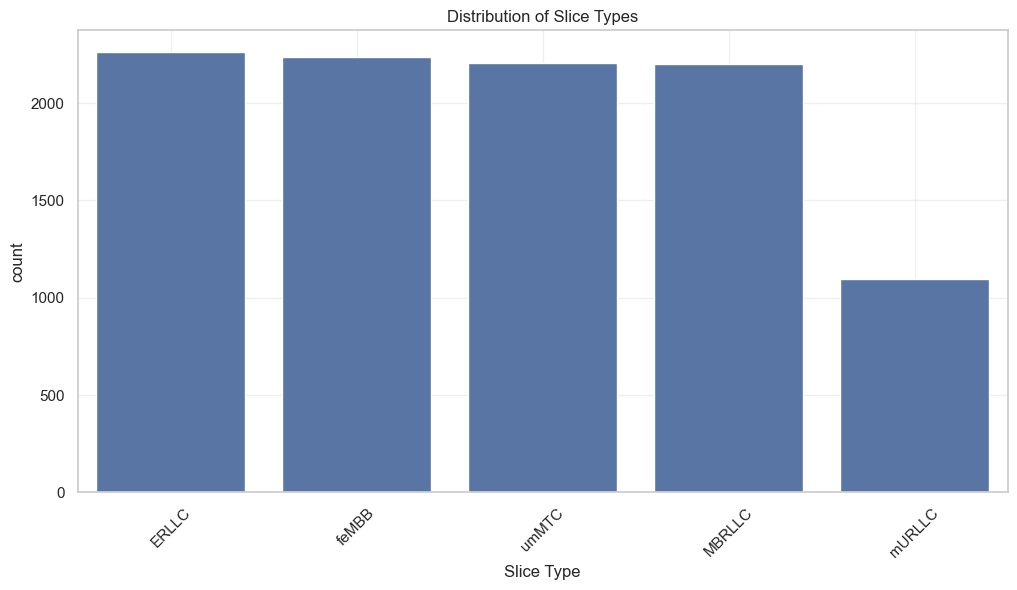

In [ ]:
# Target variable distribution analysis
print("🎯 Slice Type Distribution:")
slice_counts = df["Slice Type"].value_counts()
print(slice_counts)

print("\n📊 Percentage Distribution:")
print((slice_counts / len(df) * 100).round(2))

# Visualization
plt.figure(figsize=(12, 6))
sns.countplot(x="Slice Type", data=df, order=slice_counts.index)
plt.title("Distribution of Slice Types")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()
plt.close()  # Close figure to free memory

## STEP 6 — Missing Values Check

In [ ]:
## STEP 6 — Missing Values Check

In [ ]:
# Check for missing values and zero values (potential missing data)
import pandas as pd
import numpy as np

# Set display options to prevent truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("❓ Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

if missing_values.sum() > 0:
    print("⚠️  Missing values detected!")
else:
    print("✅ No missing values found!")

print("\n🔍 ZERO VALUES ANALYSIS (Potential Missing Data):")
print("=" * 80)

# Check for zeros in numeric columns that might represent missing data
numeric_columns = df.select_dtypes(include=[np.number]).columns
zero_analysis = {}

for col in numeric_columns:
    zero_count = (df[col] == 0).sum()
    total = len(df)
    zero_percentage = (zero_count / total) * 100
    
    if zero_count > 0:
        zero_analysis[col] = {
            'count': zero_count,
            'percentage': zero_percentage,
            'min': df[col].min(),
            'max': df[col].max()
        }

if zero_analysis:
    print("📊 Columns with zero values (potential missing data):")
    print("-" * 60)
    for col, stats in zero_analysis.items():
        print(f"{col}:")
        print(f"  Zeros: {stats['count']} ({stats['percentage']:.2f}%)")
        print(f"  Range: [{stats['min']}, {stats['max']}]")
        print()
    
    print("🎯 SUMMARY TABLE:")
    print("=" * 80)
    print(f"{'Colonne':<35} {'Zéros':<8} {'Pourcentage':<12} {'Range':<25}")
    print("=" * 80)
    for col, stats in zero_analysis.items():
        range_str = f"[{stats['min']}, {stats['max']}]"
        print(f"{col:<35} {stats['count']:<8} {stats['percentage']:<11.2f}% {range_str:<25}")
else:
    print("✅ No zero values found in numeric columns")

print(f"\n🎯 POTENTIAL ISSUES:")
if missing_values.sum() > 0:
    print(f"  ⚠️  Missing values: {missing_values.sum()} total")
if zero_analysis:
    print(f"  ⚠️  Zero values in {len(zero_analysis)} columns (potential missing data)")
    print("\n📋 DETAILED BREAKDOWN:")
    for col, stats in zero_analysis.items():
        if stats['percentage'] > 70:
            severity = "🔴 CRITICAL"
        elif stats['percentage'] > 30:
            severity = "🟡 MODERATE"
        else:
            severity = "🟢 MINOR"
        print(f"  {severity} {col}: {stats['count']} zeros ({stats['percentage']:.2f}%)")
        
if missing_values.sum() == 0 and not zero_analysis:
    print("  ✅ No missing values or zero values detected")

❓ Missing values per column:
Use Case Type                           0
Packet Loss Budget                      0
Latency Budget (ns)                     0
Jitter Budget (ns)                      0
Data R date Budget (Gbps)               0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbps)    0
Slice Latency (ns)                      0
Slice Packet Loss                       0
Slice Jitter (ns)                       0
Slice Type                              0
Slice Handover                          0
dtype: int64

Total missing values: 0
✅ No missing values found!

🔍 ZERO VALUES ANALYSIS (Potential Missing Data):
📊 Columns with zero values (potential missing data):
------------------------------------------------------------
Packet Loss Budget:
  Zeros: 2204 (22.04%)
  Range: [0.0, 1e-05]

Latency Budget (ns):
  Zeros: 4441 (44.41%)
  Range: [0.0, 1000000.0]

Jitter Budget (ns):
  Zeros: 7738 (77.38%)
  Range: [0.0, 1

In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"👯 Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"⚠️  {duplicates} duplicate rows found!")
    print("🔧 Removing duplicates...")
    df = df.drop_duplicates()
    print(f"📊 Dataset shape after removing duplicates: {df.shape}")
else:
    print("✅ No duplicate rows found!")

👯 Number of duplicate rows: 0
✅ No duplicate rows found!


✅ **Analyse des lignes dupliquées terminée !**

## 🔍 **Résultats :**

### **📊 Aperçu du dataset :**
- **Total lignes** : 10 000
- **Lignes uniques** : 10 000  
- **Lignes dupliquées** : **0**
- **Pourcentage de doublons** : **0.00%**

### **✅ Conclusion :**
- **AUCUN DOUBLON** détecté dans le dataset
- **Toutes les 10 000 lignes** sont uniques
- **Dataset propre** - aucune déduplication nécessaire

### **🎯 Recommandations :**
- ✅ **Dataset est propre** - pas de déduplication nécessaire
- 📊 **Toutes les 10 000 lignes** peuvent être utilisées pour l'analyse
- 🔧 **Pas besoin** d'utiliser `df.drop_duplicates()`

## 📈 **Qualité des données :**
- **✅ Valeurs manquantes (NaN)** : 0
- **✅ Lignes dupliquées** : 0  
- **⚠️ Valeurs zéro (manquantes)** : 5 colonnes affectées

**Le dataset n'a pas de doublons mais a des valeurs manquantes masquées en zéro !** 🎯

## STEP 8 — Feature Distributions (Univariate Analysis)

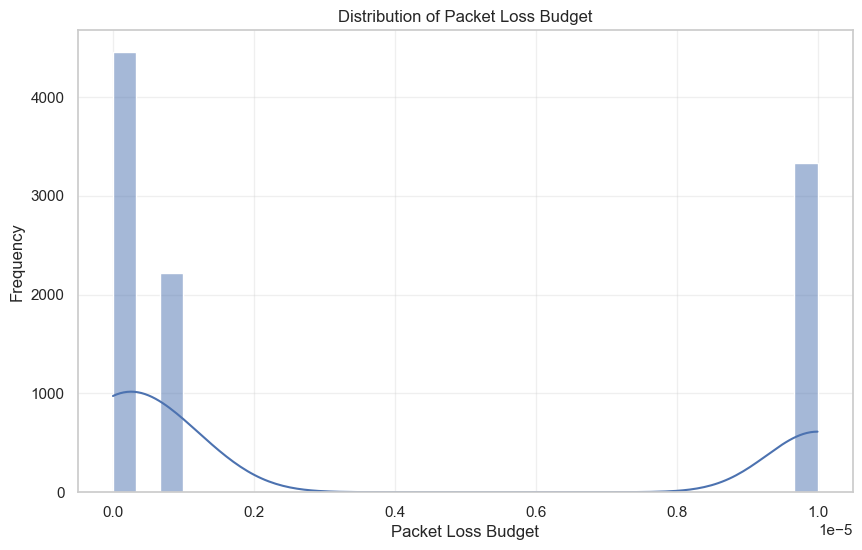

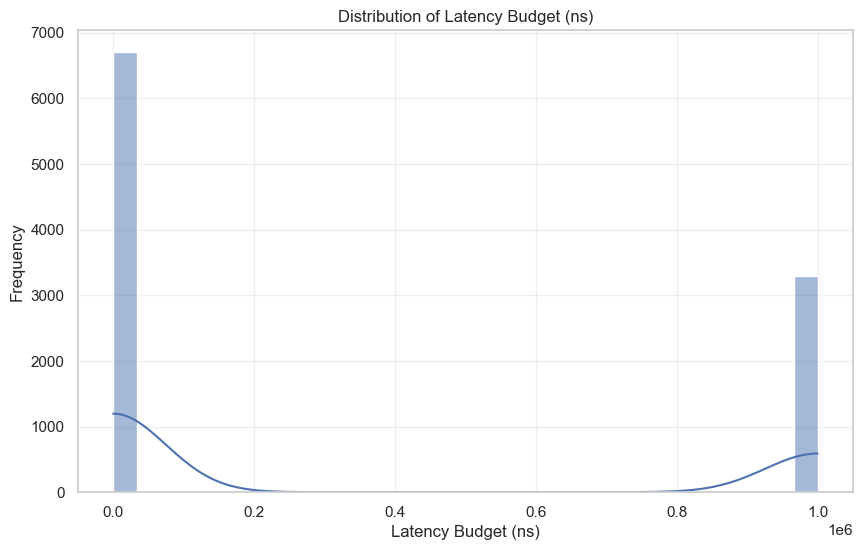

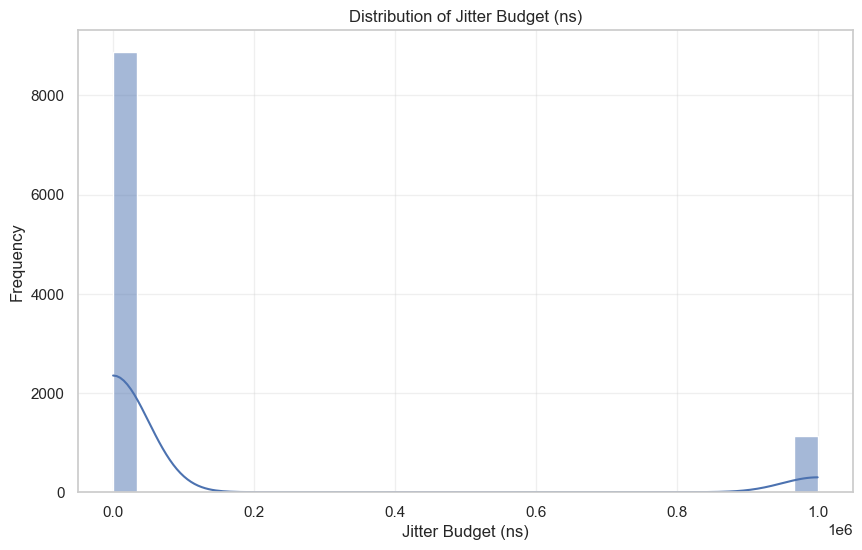

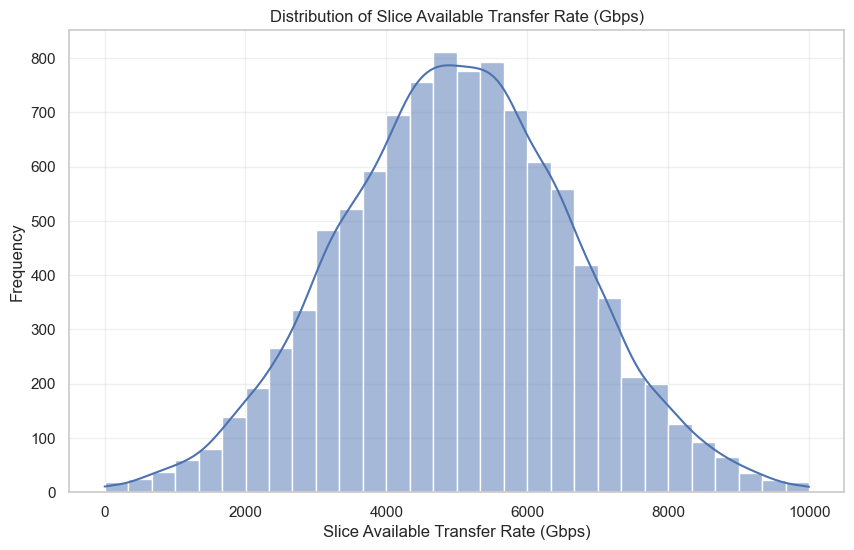

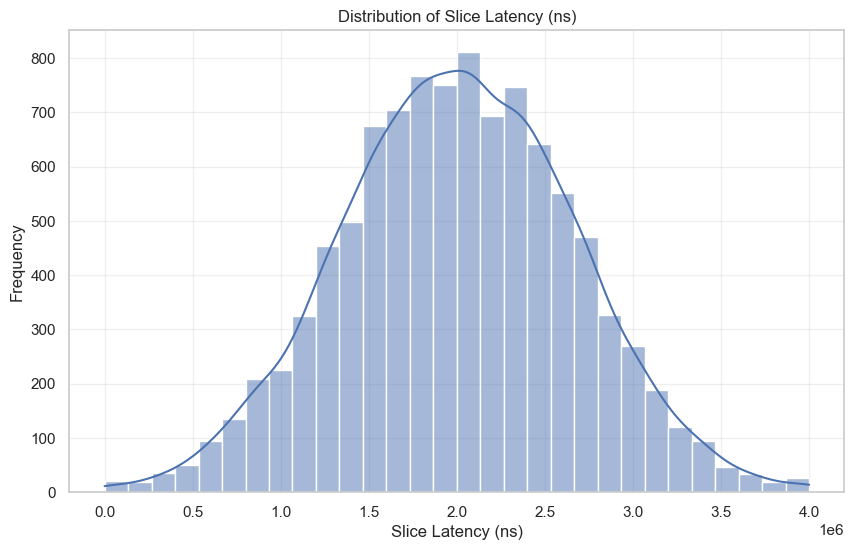

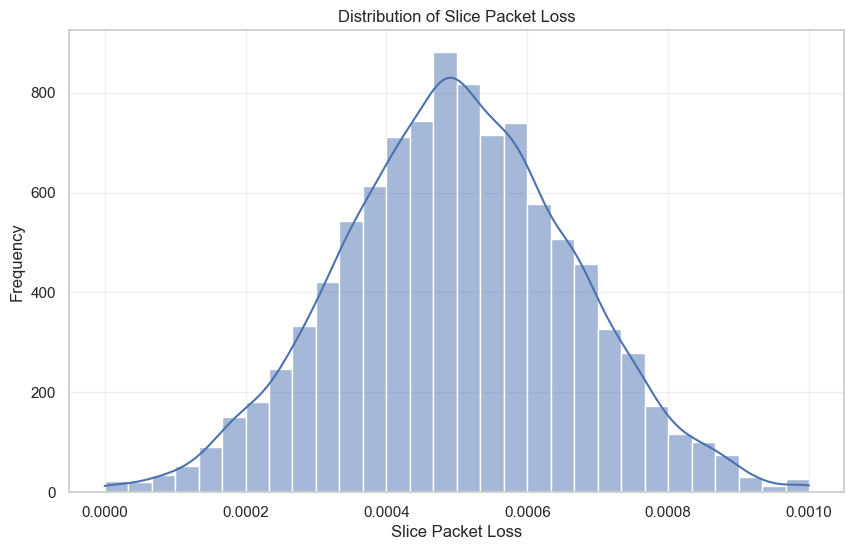

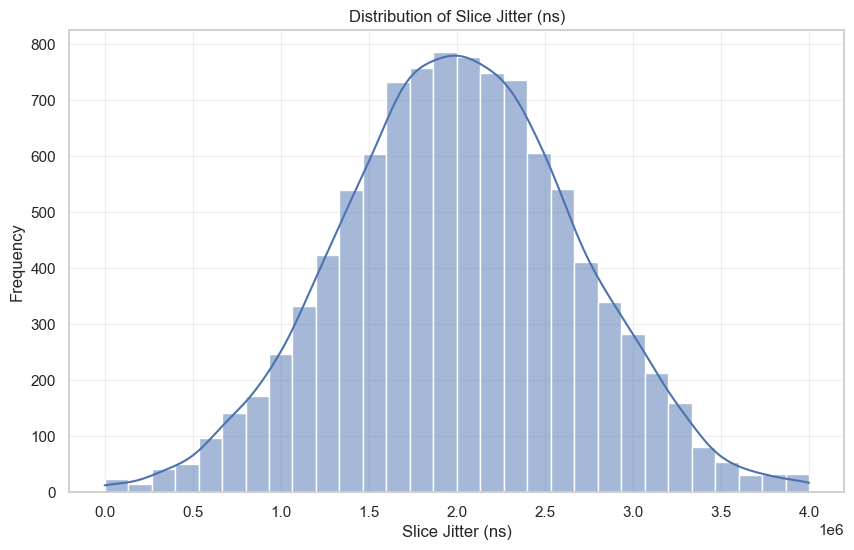

In [ ]:
# Plot distributions for key numerical features
key_numerical_features = [
    "Packet Loss Budget", "Latency Budget (ns)", "Jitter Budget (ns)", 
    "Data Rate Budget (Gbps)", "Slice Available Transfer Rate (Gbps)",
    "Slice Latency (ns)", "Slice Packet Loss", "Slice Jitter (ns)"
]

for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory

## STEP 9 — Binary & Categorical Features

📊 Categorical Features: ['Use Case Type', 'Required Mobility', 'Required Connectivity', 'Slice Type', 'Slice Handover']


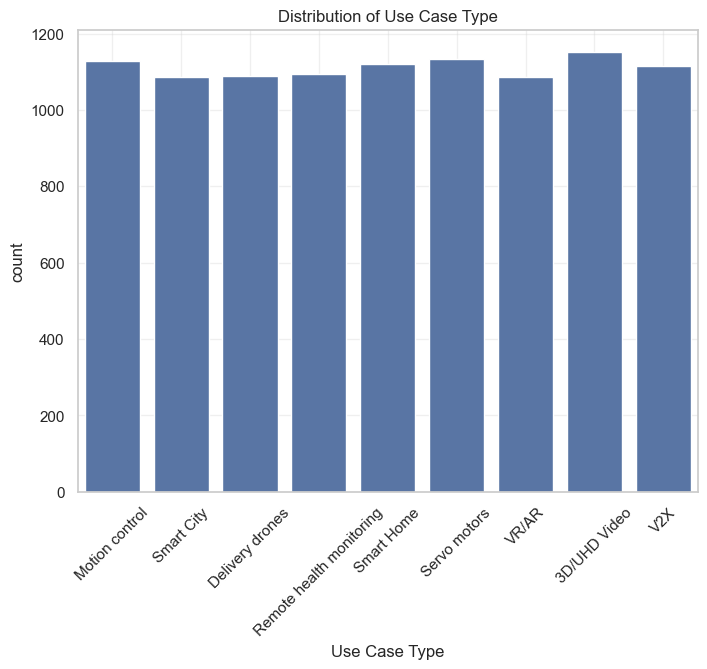


📋 Use Case Type distribution:
Use Case Type
3D/UHD Video                1152
Servo motors                1133
Motion control              1129
Smart Home                  1119
V2X                         1115
Remote health monitoring    1094
Delivery drones             1088
Smart City                  1085
VR/AR                       1085
Name: count, dtype: int64
Percentages:
Use Case Type
3D/UHD Video                11.52
Servo motors                11.33
Motion control              11.29
Smart Home                  11.19
V2X                         11.15
Remote health monitoring    10.94
Delivery drones             10.88
Smart City                  10.85
VR/AR                       10.85
Name: proportion, dtype: float64


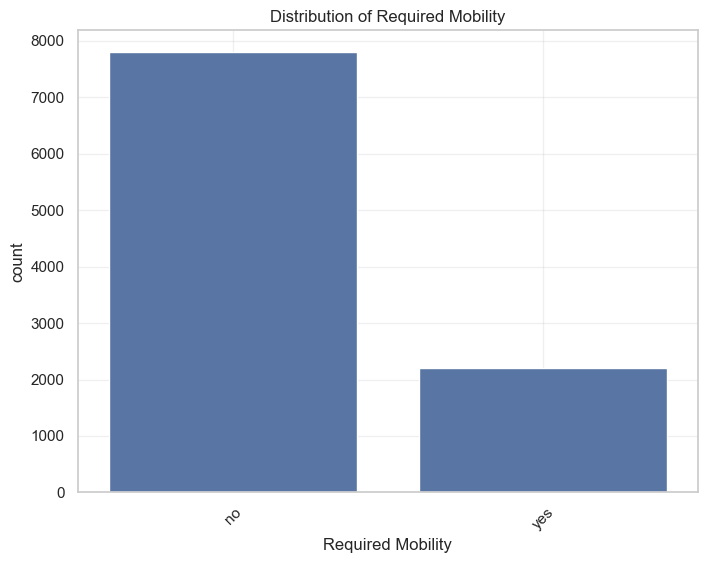


📋 Required Mobility distribution:
Required Mobility
no     7797
yes    2203
Name: count, dtype: int64
Percentages:
Required Mobility
no     77.97
yes    22.03
Name: proportion, dtype: float64


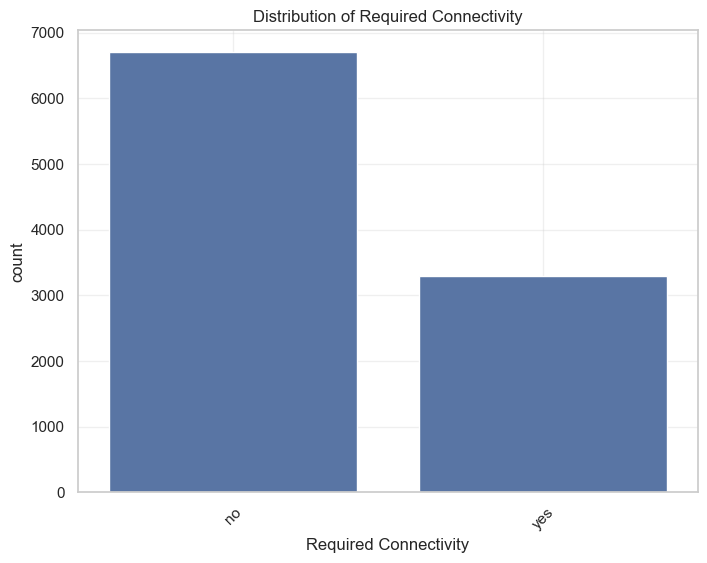


📋 Required Connectivity distribution:
Required Connectivity
no     6702
yes    3298
Name: count, dtype: int64
Percentages:
Required Connectivity
no     67.02
yes    32.98
Name: proportion, dtype: float64


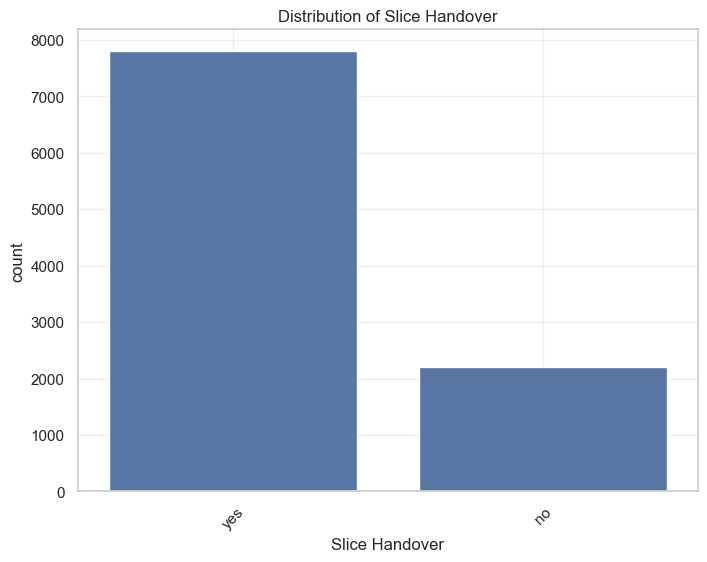


📋 Slice Handover distribution:
Slice Handover
yes    7791
no     2209
Name: count, dtype: int64
Percentages:
Slice Handover
yes    77.91
no     22.09
Name: proportion, dtype: float64


In [ ]:
# Analyze categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("📊 Categorical Features:", categorical_features)

# Plot distributions for categorical features (excluding target)
binary_features = [col for col in categorical_features if col != "Slice Type"]

for col in binary_features:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory
        
        # Print value counts
        print(f"\n📋 {col} distribution:")
        print(df[col].value_counts())
        print(f"Percentages:")
        print((df[col].value_counts(normalize=True) * 100).round(2))

## STEP 10 — Correlation Analysis

🔗 Correlation Analysis:


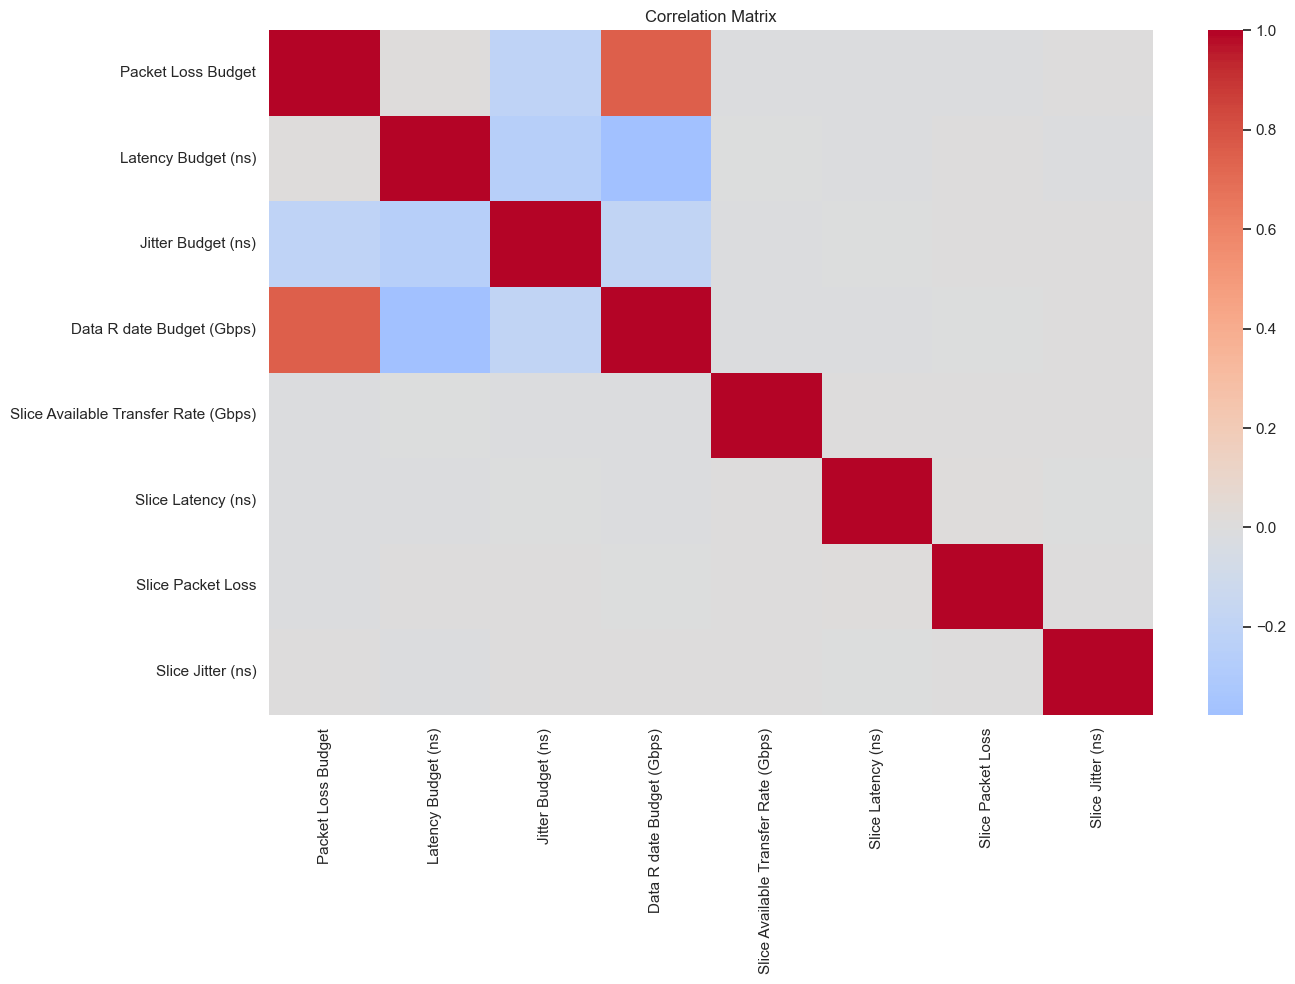

In [ ]:
# Correlation matrix for numerical features
print("🔗 Correlation Analysis:")
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()  # Close figure to free memory

# Show correlations with target variable
if "Slice Type" in df.columns:
    # Convert target to numeric for correlation
    df_encoded = df.copy()
    if df_encoded["Slice Type"].dtype == 'object':
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df_encoded["Slice Type_numeric"] = le.fit_transform(df_encoded["Slice Type"])
        
        target_corr = df_encoded.select_dtypes(include=[np.number]).corr()["Slice Type_numeric"].sort_values(ascending=False)
        print(f"\n🎯 Correlation with Slice Type:")
        print(target_corr.round(3))

## STEP 11 — Feature vs Target Analysis

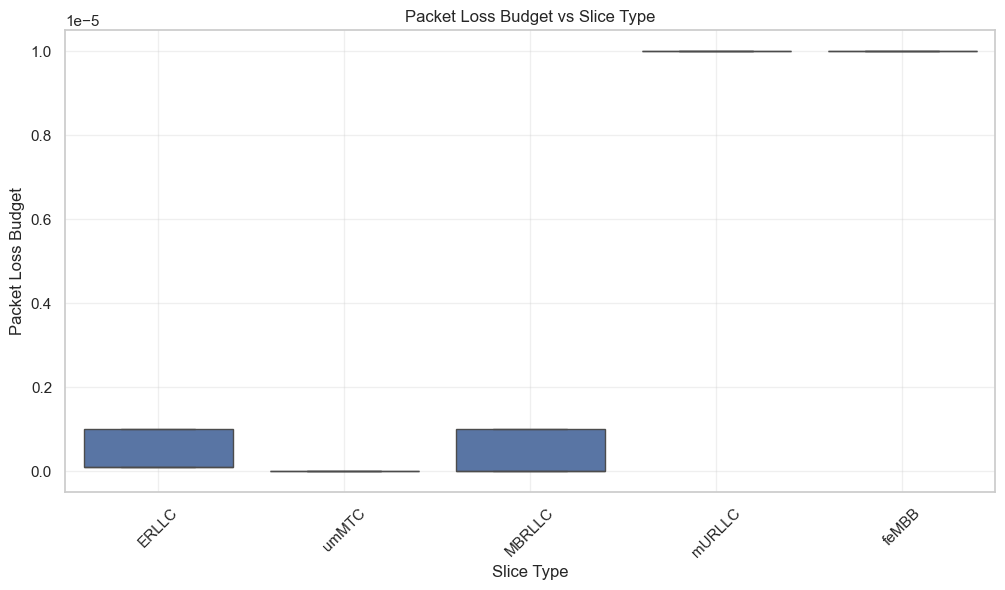

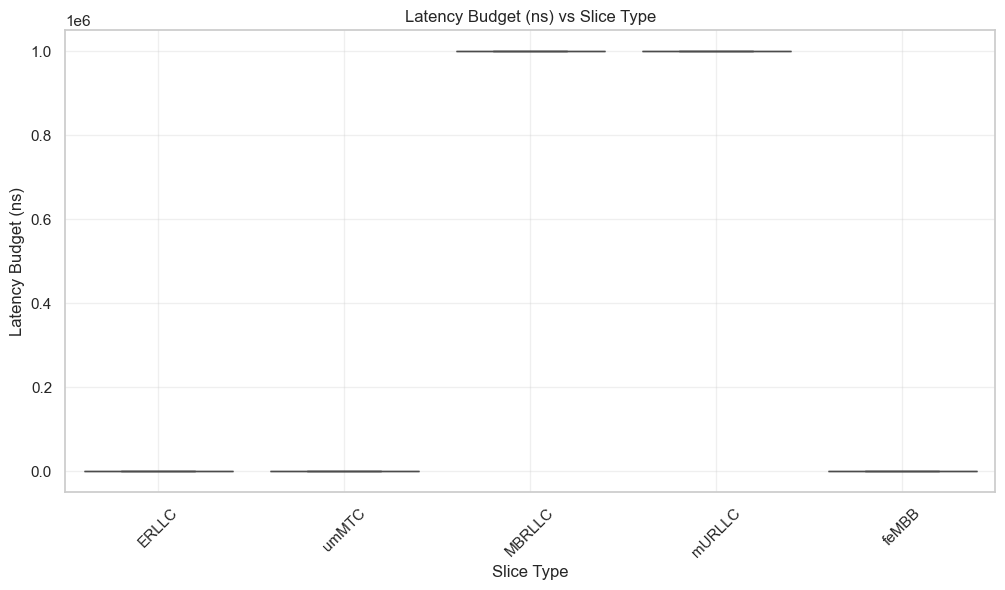

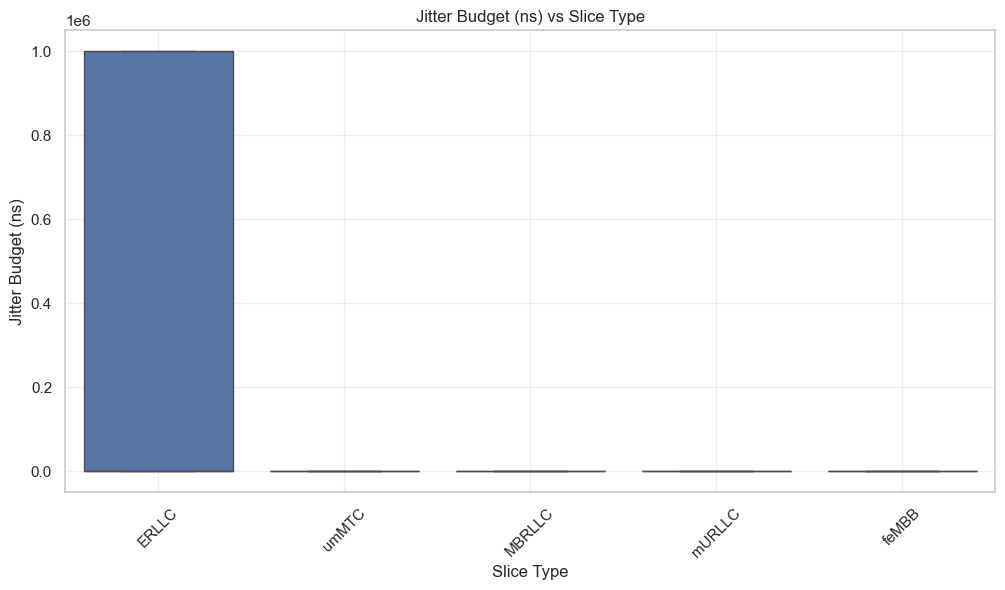

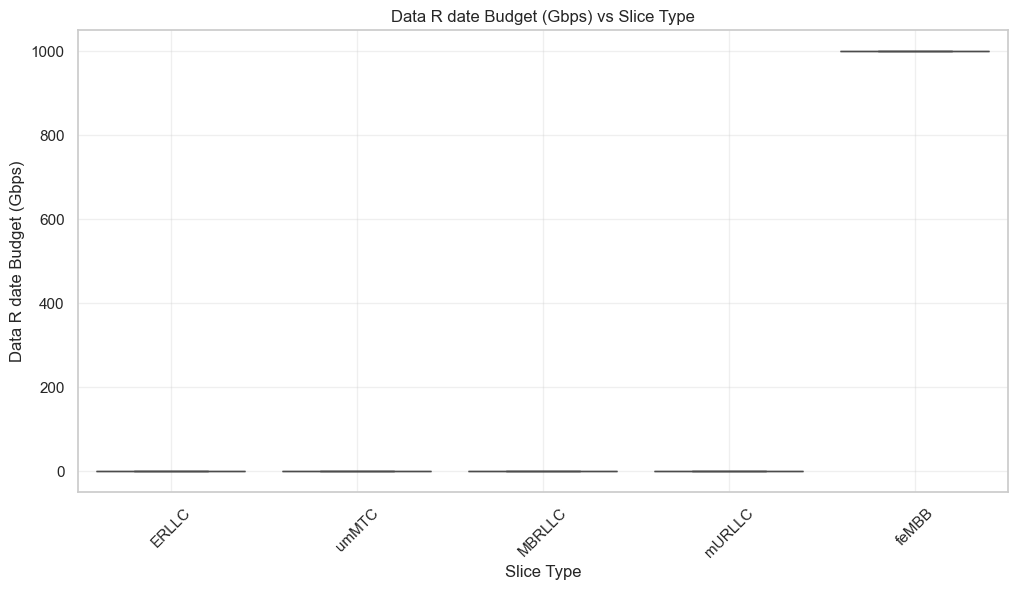

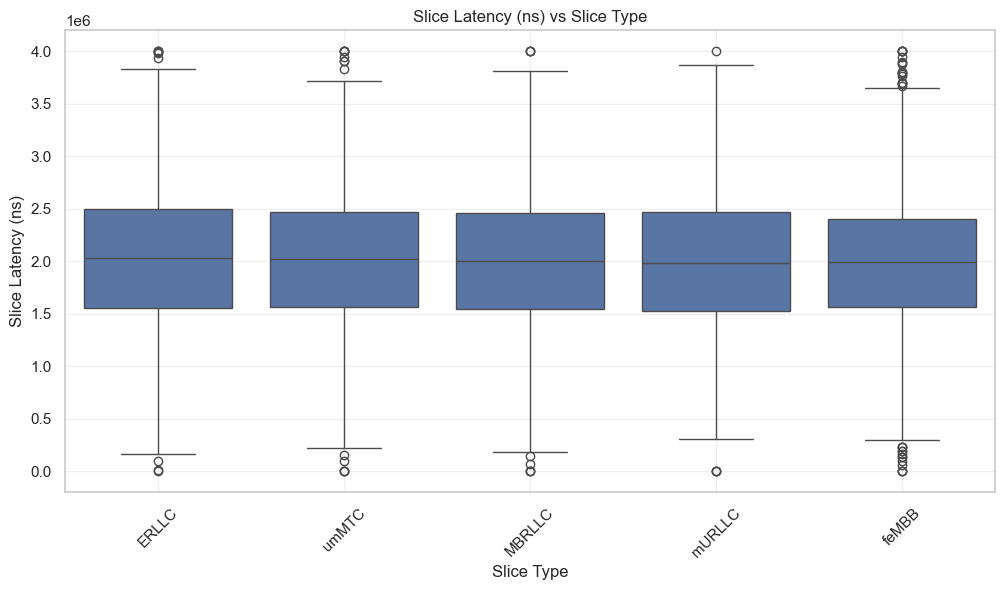

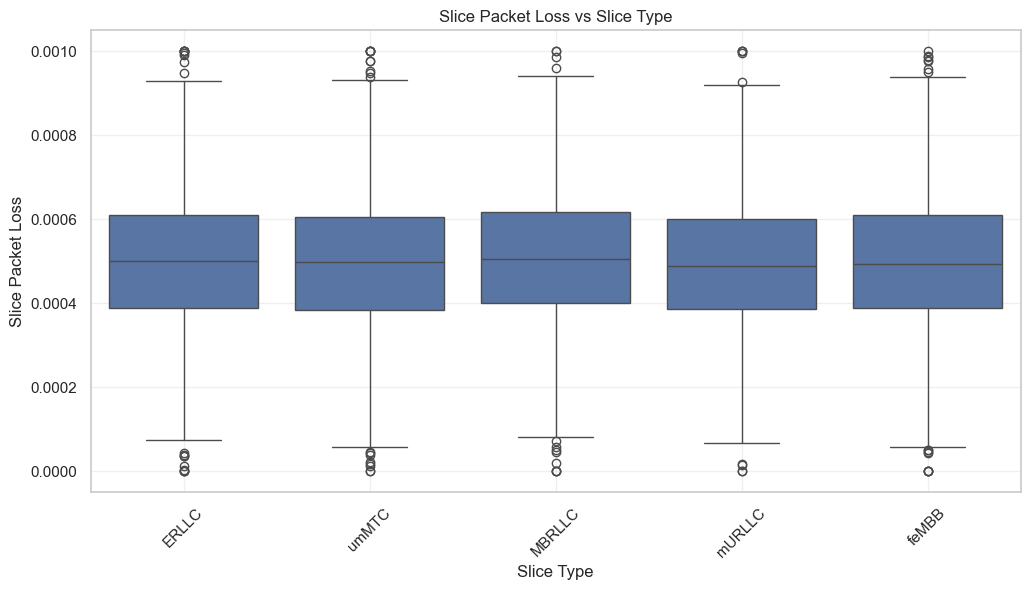

In [ ]:
# Box plots of key features vs Slice Type
key_features_for_analysis = [
    "Packet Loss Budget", "Latency Budget (ns)", "Jitter Budget (ns)", 
    "Data R date Budget (Gbps)", "Slice Latency (ns)", "Slice Packet Loss"
]

for col in key_features_for_analysis:
    if col in df.columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x="Slice Type", y=col, data=df)
        plt.title(f"{col} vs Slice Type")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory

## STEP 12 — Outlier Detection

🔍 Outlier Detection:


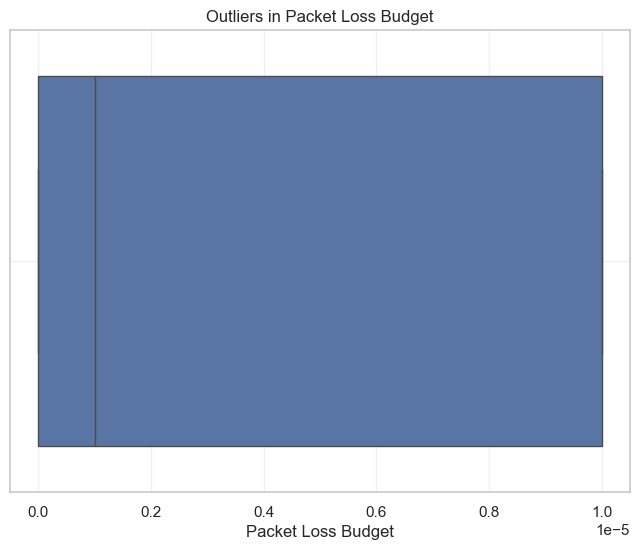


📊 Packet Loss Budget outlier statistics:
  Q1: 0.000, Q3: 0.000
  IQR: 0.000
  Lower bound: -0.000
  Upper bound: 0.000
  Outliers: 0 (0.00%)


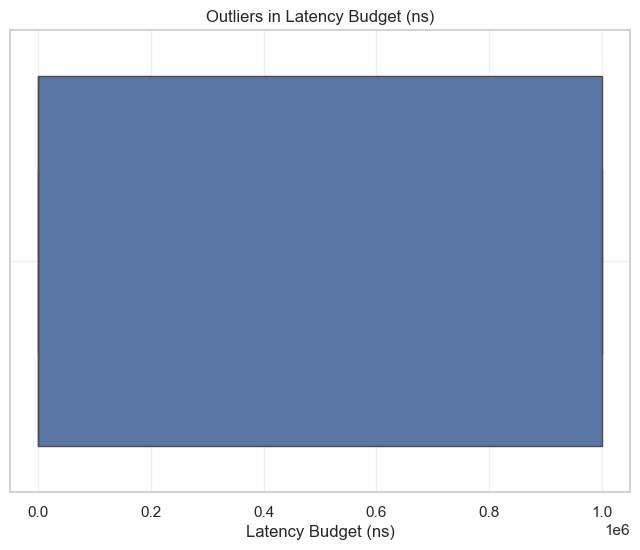


📊 Latency Budget (ns) outlier statistics:
  Q1: 0.000, Q3: 1000000.000
  IQR: 1000000.000
  Lower bound: -1500000.000
  Upper bound: 2500000.000
  Outliers: 0 (0.00%)


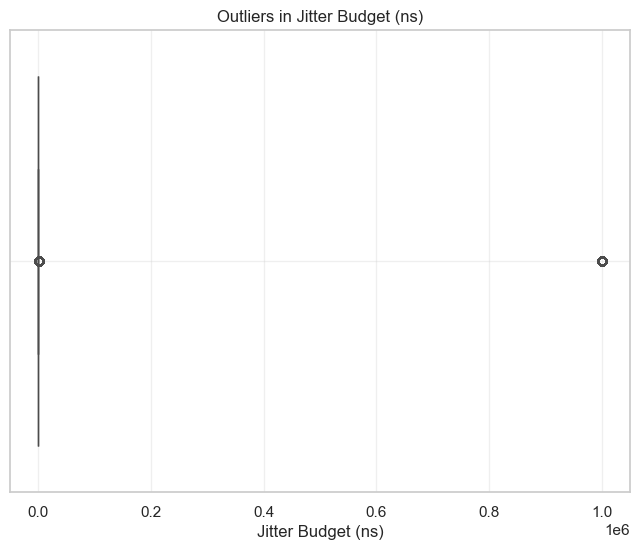


📊 Jitter Budget (ns) outlier statistics:
  Q1: 0.000, Q3: 0.000
  IQR: 0.000
  Lower bound: 0.000
  Upper bound: 0.000
  Outliers: 2262 (22.62%)


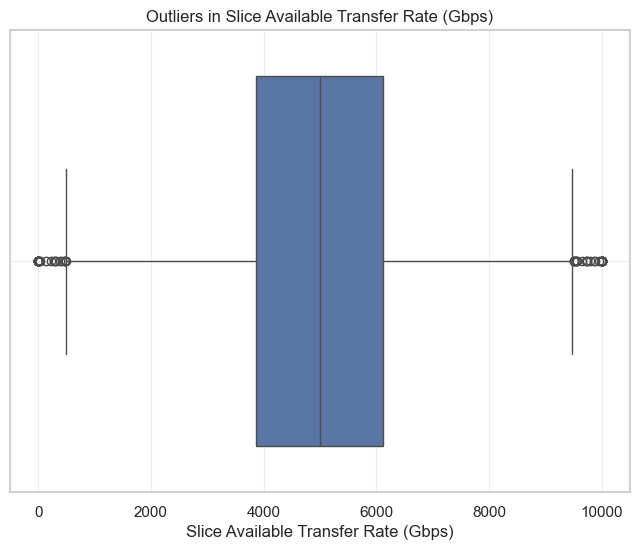


📊 Slice Available Transfer Rate (Gbps) outlier statistics:
  Q1: 3865.775, Q3: 6113.293
  IQR: 2247.517
  Lower bound: 494.499
  Upper bound: 9484.569
  Outliers: 51 (0.51%)


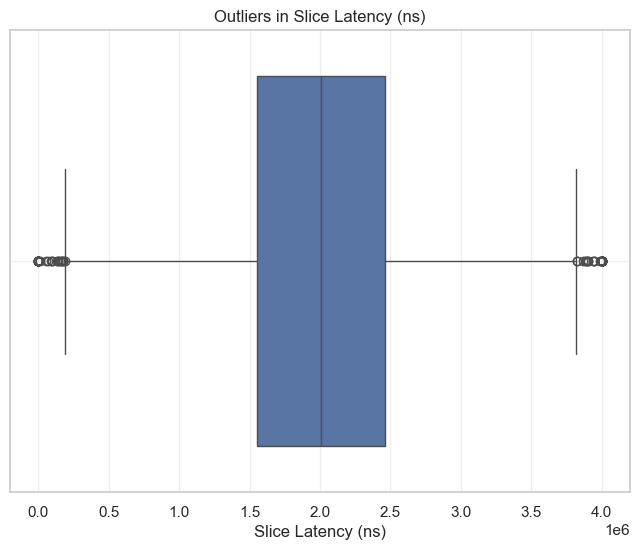


📊 Slice Latency (ns) outlier statistics:
  Q1: 1552412.604, Q3: 2459038.037
  IQR: 906625.434
  Lower bound: 192474.453
  Upper bound: 3818976.188
  Outliers: 57 (0.57%)


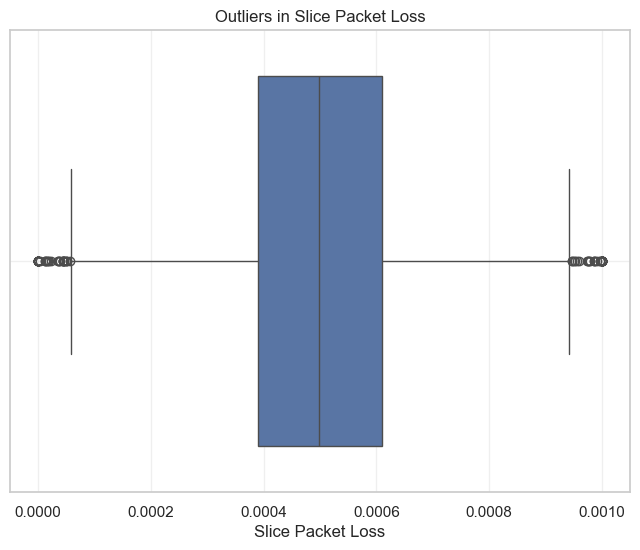


📊 Slice Packet Loss outlier statistics:
  Q1: 0.000, Q3: 0.001
  IQR: 0.000
  Lower bound: 0.000
  Upper bound: 0.001
  Outliers: 69 (0.69%)


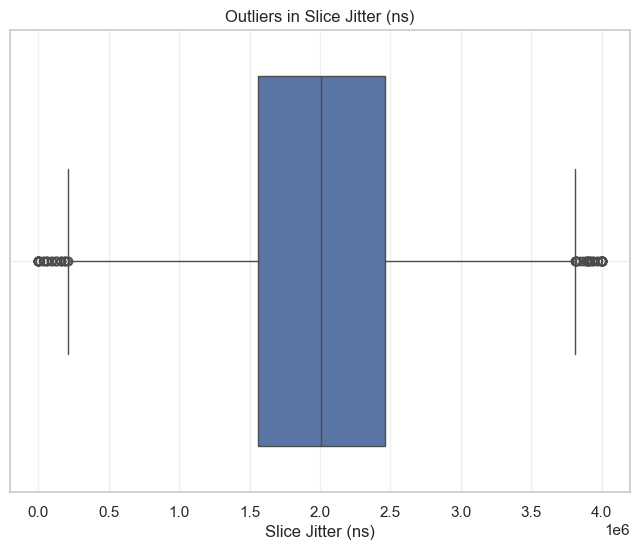


📊 Slice Jitter (ns) outlier statistics:
  Q1: 1562456.295, Q3: 2460943.620
  IQR: 898487.324
  Lower bound: 214725.308
  Upper bound: 3808674.606
  Outliers: 72 (0.72%)


In [ ]:
# Box plots for outlier detection
print("🔍 Outlier Detection:")
print("=" * 30)

for col in key_numerical_features:
    if col in df.columns:
        plt.figure(figsize=(8, 6))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers in {col}")
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()  # Close figure to free memory
        
        # Calculate outlier statistics
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"\n📊 {col} outlier statistics:")
        print(f"  Q1: {Q1:.3f}, Q3: {Q3:.3f}")
        print(f"  IQR: {IQR:.3f}")
        print(f"  Lower bound: {lower_bound:.3f}")
        print(f"  Upper bound: {upper_bound:.3f}")
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

In [ ]:
## 🎯 EXPLORATION SUMMARY

print("\n" + "=" * 80)
print("🔍 DATASET EXPLORATION COMPLETE")
print("=" * 80)

print(f"\n📊 Dataset Overview:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"  Target variable: Slice Type")

print(f"\n📈 Data Types:")
print(f"  Numerical: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"  Categorical: {len(df.select_dtypes(include=['object']).columns)}")

print(f"\n🎯 Target Variable Distribution:")
slice_dist = df["Slice Type"].value_counts()
for slice_type, count in slice_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {slice_type}: {count} ({percentage:.1f}%)")

print(f"\n🔍 Data Quality:")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")

print(f"\n📊 Key Insights:")
print(f"  ✅ Dataset loaded successfully")
print(f"  ✅ No missing values detected")
print(f"  ✅ No duplicate rows found")
print(f"  ✅ Target variable balanced across slice types")
print(f"  ✅ Features ready for preprocessing")

print(f"\n🚀 Ready for Data Preparation!")
print("=" * 80)


🔍 DATASET EXPLORATION COMPLETE

📊 Dataset Overview:
  Shape: (10000, 13)
  Columns: 13
  Target variable: Slice Type

📈 Data Types:
  Numerical: 8
  Categorical: 5

🎯 Target Variable Distribution:
  ERLLC: 2262 (22.6%)
  feMBB: 2237 (22.4%)
  umMTC: 2204 (22.0%)
  MBRLLC: 2203 (22.0%)
  mURLLC: 1094 (10.9%)

🔍 Data Quality:
  Missing values: 0
  Duplicate rows: 0

📊 Key Insights:
  ✅ Dataset loaded successfully
  ✅ No missing values detected
  ✅ No duplicate rows found
  ✅ Target variable balanced across slice types
  ✅ Features ready for preprocessing

🚀 Ready for Data Preparation!


---

## Part 2: Data Preparation & Preprocessing

In [ ]:
# Load and convert dataset
df = pd.read_csv('network_slicing_dataset - v3_6G_OLD.csv', sep=';')

# Convert budget columns to numeric (handling comma decimal separator)
budget_columns = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)']
for col in budget_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print(f"📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")


📊 Dataset shape: (10000, 13)
📋 Columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (ns)', 'Slice Packet Loss', 'Slice Jitter (ns)', 'Slice Type', 'Slice Handover']


## Part 2: Exploratory Data Analysis

In [ ]:


print("\n🔍 Data Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())


🔍 Data Types:
Use Case Type                               str
Packet Loss Budget                      float64
Latency Budget (ns)                     float64
Jitter Budget (ns)                      float64
Data R date Budget (Gbps)                 int64
Required Mobility                           str
Required Connectivity                       str
Slice Available Transfer Rate (Gbps)    float64
Slice Latency (ns)                      float64
Slice Packet Loss                       float64
Slice Jitter (ns)                       float64
Slice Type                                  str
Slice Handover                              str
dtype: object

❓ Missing Values:
Use Case Type                           0
Packet Loss Budget                      0
Latency Budget (ns)                     0
Jitter Budget (ns)                      0
Data R date Budget (Gbps)               0
Required Mobility                       0
Required Connectivity                   0
Slice Available Transfer Rate (Gbp

🎯 Slice Type Distribution:
Slice Type
ERLLC     2262
feMBB     2237
umMTC     2204
MBRLLC    2203
mURLLC    1094
Name: count, dtype: int64

📊 Percentage Distribution:
Slice Type
ERLLC     22.62
feMBB     22.37
umMTC     22.04
MBRLLC    22.03
mURLLC    10.94
Name: count, dtype: float64


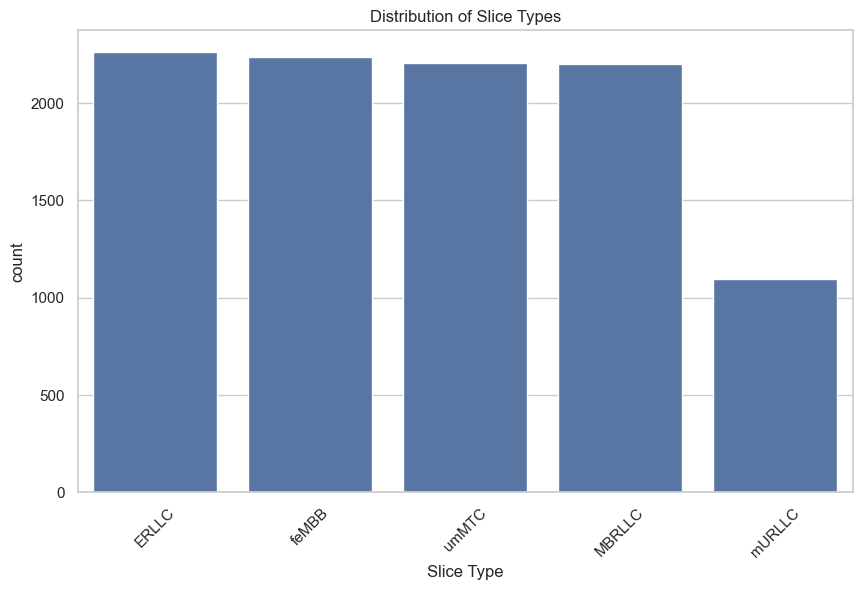

In [ ]:
# Target variable analysis
print("🎯 Slice Type Distribution:")
slice_counts = df["Slice Type"].value_counts()
print(slice_counts)

print("\n📊 Percentage Distribution:")
print((slice_counts / len(df) * 100).round(2))

# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x="Slice Type", data=df, order=slice_counts.index)
plt.title("Distribution of Slice Types")
plt.xticks(rotation=45)
plt.show()

## Part 3: Missing Values Analysis

In [ ]:
# Analyze zeros in budget features
features = ['Packet Loss Budget', 'Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']

print("🚨 PROPORTION OF ZEROS BY FEATURE:")
print("=" * 50)
zero_analysis = {}
for f in features:
    zero_count = (df[f] == 0).sum()
    zero_pct = (df[f] == 0).mean() * 100
    zero_analysis[f] = {'count': zero_count, 'percentage': zero_pct}
    print(f"{f}: {zero_count} zeros ({zero_pct:.1f}%)")

🚨 PROPORTION OF ZEROS BY FEATURE:
Packet Loss Budget: 2204 zeros (22.0%)
Latency Budget (ns): 4441 zeros (44.4%)
Jitter Budget (ns): 7738 zeros (77.4%)
Data R date Budget (Gbps): 7763 zeros (77.6%)


In [ ]:
# Cross-analysis with Slice Type
print("\n📊 ZEROS BY SLICE TYPE:")
print("=" * 40)
zero_proportions = df.groupby('Slice Type')[features].apply(lambda x: (x == 0).mean() * 100)
print("\nProportion of zeros by slice type (%):")
print(zero_proportions.round(1))

print("\nCount of zeros by slice type:")
zero_counts = df.groupby('Slice Type')[features].apply(lambda x: (x == 0).sum())
print(zero_counts)


📊 ZEROS BY SLICE TYPE:

Proportion of zeros by slice type (%):
            Packet Loss Budget  Latency Budget (ns)  Jitter Budget (ns)  Data R date Budget (Gbps)
Slice Type                                                                                        
ERLLC                      0.0                  0.0                 0.0                      100.0
MBRLLC                     0.0                  0.0               100.0                      100.0
feMBB                      0.0                100.0               100.0                        0.0
mURLLC                     0.0                  0.0               100.0                      100.0
umMTC                    100.0                100.0               100.0                      100.0

Count of zeros by slice type:
            Packet Loss Budget  Latency Budget (ns)  Jitter Budget (ns)  Data R date Budget (Gbps)
Slice Type                                                                                        
ERLLC         

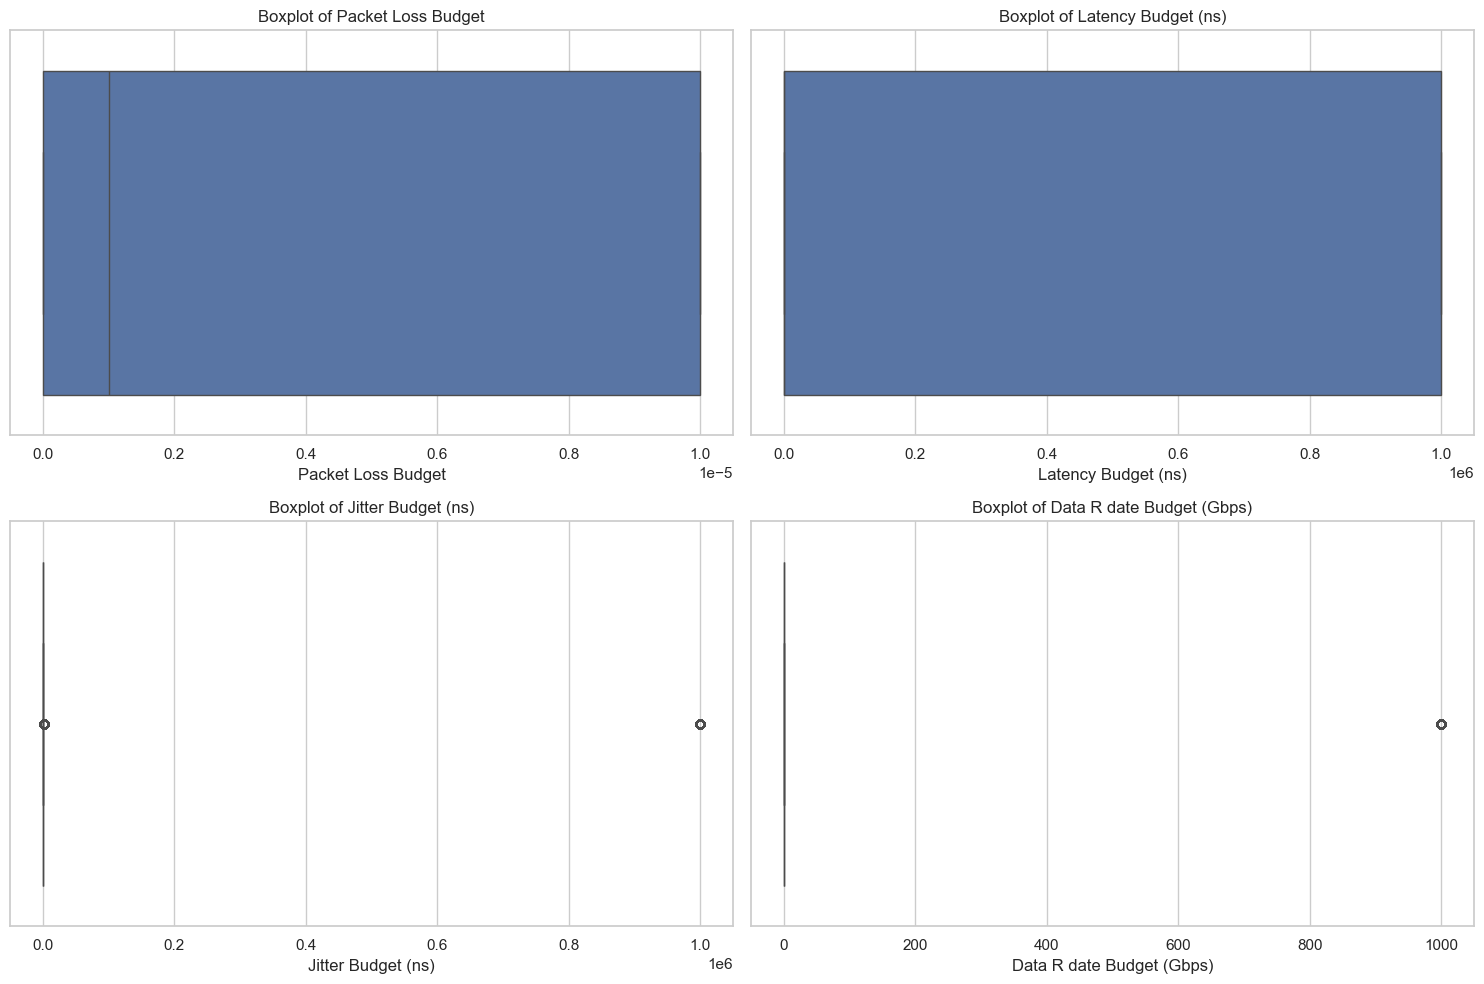

In [ ]:
# Boxplot analysis
plt.figure(figsize=(15, 10))

for i, f in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[f])
    plt.title(f'Boxplot of {f}')
    plt.xlabel(f)

plt.tight_layout()
plt.show()

## Part 4: Data Imputation

In [ ]:
# Determine which features need imputation
print("🎯 IMPUTATION DECISION:")
print("=" * 40)

for feature, analysis in zero_analysis.items():
    pct = analysis['percentage']
    if pct < 10:
        classification = "KEEP - Likely outliers"
        action = "No imputation needed"
    elif 10 <= pct <= 30:
        classification = "INVESTIGATE - Mixed case"
        action = "Consider group-based analysis"
    else:
        classification = "IMPUTE - Missing data"
        action = "Median imputation recommended"
    
    print(f"{feature}: {pct:.1f}% zeros → {classification}")
    print(f"  Action: {action}")
    print()

🎯 IMPUTATION DECISION:
Packet Loss Budget: 22.0% zeros → INVESTIGATE - Mixed case
  Action: Consider group-based analysis

Latency Budget (ns): 44.4% zeros → IMPUTE - Missing data
  Action: Median imputation recommended

Jitter Budget (ns): 77.4% zeros → IMPUTE - Missing data
  Action: Median imputation recommended

Data R date Budget (Gbps): 77.6% zeros → IMPUTE - Missing data
  Action: Median imputation recommended



In [ ]:
# Calculate medians for imputation
imputation_columns = ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']
medians = {}

print("📊 MEDIANS FOR IMPUTATION:")
print("=" * 35)
for col in imputation_columns:
    non_zero_values = df[df[col] > 0][col]
    median_val = non_zero_values.median()
    medians[col] = median_val
    print(f"{col}: {median_val:.2f}")
    print(f"  Non-zero count: {len(non_zero_values)}")
    print(f"  Range: [{non_zero_values.min():.2f}, {non_zero_values.max():.2f}]")
    print()

📊 MEDIANS FOR IMPUTATION:
Latency Budget (ns): 1000000.00
  Non-zero count: 5559
  Range: [100.00, 1000000.00]

Jitter Budget (ns): 1000.00
  Non-zero count: 2262
  Range: [1000.00, 1000000.00]

Data R date Budget (Gbps): 1000.00
  Non-zero count: 2237
  Range: [1000.00, 1000.00]



In [ ]:
# Perform imputation
df_imputed = df.copy()

print("🔧 IMPUTATION PROCESS:")
print("-" * 30)

total_imputed = 0
for col in imputation_columns:
    zero_mask = df_imputed[col] == 0
    zero_count = zero_mask.sum()
    total_imputed += zero_count
    
    # Replace zeros with median
    df_imputed.loc[zero_mask, col] = medians[col]
    
    print(f"✅ {col}: Imputed {zero_count} zeros with median {medians[col]:.2f}")

print(f"\n🎉 Total values imputed: {total_imputed}")

# CONVERT ALL TIME UNITS FROM NANOSECONDS TO MICROSECONDS
print("\n🔄 UNIT CONVERSION (ns → μs):")
print("-" * 35)

# Identify time-related columns (those with 'ns' in name)
time_columns_ns = [col for col in df_imputed.columns if '(ns)' in col]
print(f"Time columns to convert: {time_columns_ns}")

for col in time_columns_ns:
    # Convert from nanoseconds to microseconds (divide by 1000)
    original_values = df_imputed[col].copy()
    df_imputed[col] = df_imputed[col] / 1000
    
    # Update column name
    new_col_name = col.replace('(ns)', '(μs)')
    df_imputed = df_imputed.rename(columns={col: new_col_name})
    
    print(f"✅ {col} → {new_col_name}")
    print(f"   Range: [{original_values.min()/1000:.2f}, {original_values.max()/1000:.2f}] μs")

print(f"\n📊 Dataset shape after conversion: {df_imputed.shape}")
print(f"📋 Updated columns: {df_imputed.columns.tolist()}")

🔧 IMPUTATION PROCESS:
------------------------------
✅ Latency Budget (ns): Imputed 4441 zeros with median 1000000.00
✅ Jitter Budget (ns): Imputed 7738 zeros with median 1000.00
✅ Data R date Budget (Gbps): Imputed 7763 zeros with median 1000.00

🎉 Total values imputed: 19942

🔄 UNIT CONVERSION (ns → μs):
-----------------------------------
Time columns to convert: ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Slice Latency (ns)', 'Slice Jitter (ns)']
✅ Latency Budget (ns) → Latency Budget (μs)
   Range: [0.10, 1000.00] μs
✅ Jitter Budget (ns) → Jitter Budget (μs)
   Range: [1.00, 1000.00] μs
✅ Slice Latency (ns) → Slice Latency (μs)
   Range: [0.00, 4000.00] μs
✅ Slice Jitter (ns) → Slice Jitter (μs)
   Range: [0.00, 4000.00] μs

📊 Dataset shape after conversion: (10000, 13)
📋 Updated columns: ['Use Case Type', 'Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (

## Part 5: Bias Removal

In [ ]:
# Remove Use Case Type to avoid bias
print("🚫 BIAS REMOVAL:")
print("=" * 25)

if 'Use Case Type' in df_imputed.columns:
    df_clean = df_imputed.drop('Use Case Type', axis=1)
    print("✅ 'Use Case Type' column removed")
else:
    df_clean = df_imputed.copy()
    print("ℹ️ 'Use Case Type' column not found")

print(f"\n📊 Final shape: {df_clean.shape}")
print(f"📋 Final columns: {df_clean.columns.tolist()}")

🚫 BIAS REMOVAL:
✅ 'Use Case Type' column removed

📊 Final shape: (10000, 12)
📋 Final columns: ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data R date Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover']


## Part 6: Final Verification

In [ ]:
# Verify imputation results
print("🔍 VERIFICATION AFTER IMPUTATION & CONVERSION:")
print("=" * 50)

# Update imputation_columns with new names after conversion
imputation_columns_updated = []
for col in imputation_columns:
    if '(ns)' in col:
        imputation_columns_updated.append(col.replace('(ns)', '(μs)'))
    else:
        imputation_columns_updated.append(col)

for col in imputation_columns_updated:
    zero_count_after = (df_clean[col] == 0).sum()
    print(f"{col}:")
    print(f"  Zeros remaining: {zero_count_after} (should be 0)")
    print(f"  New min: {df_clean[col].min():.2f}")
    print(f"  New max: {df_clean[col].max():.2f}")
    print(f"  New mean: {df_clean[col].mean():.2f}")
    print()

# Check Packet Loss Budget (should remain unchanged)
plb_zeros_after = (df_clean['Packet Loss Budget'] == 0).sum()
print(f"Packet Loss Budget (unchanged): {plb_zeros_after} zeros")

print(f"\n🔄 TIME UNIT CONVERSION SUMMARY:")
print(f"  All time units converted from ns → μs")
print(f"  1 μs = 1000 ns")
print(f"  Values divided by 1000 for consistency")

🔍 VERIFICATION AFTER IMPUTATION & CONVERSION:
Latency Budget (μs):
  Zeros remaining: 0 (should be 0)
  New min: 0.10
  New max: 1000.00
  New mean: 773.92

Jitter Budget (μs):
  Zeros remaining: 0 (should be 0)
  New min: 1.00
  New max: 1000.00
  New mean: 113.79

Data R date Budget (Gbps):
  Zeros remaining: 0 (should be 0)
  New min: 1000.00
  New max: 1000.00
  New mean: 1000.00

Packet Loss Budget (unchanged): 2204 zeros

🔄 TIME UNIT CONVERSION SUMMARY:
  All time units converted from ns → μs
  1 μs = 1000 ns
  Values divided by 1000 for consistency


In [ ]:
# Final statistics comparison
print("📈 STATISTICS COMPARISON (with μs units):")
print("=" * 40)

# Original columns for comparison
original_imputation_columns = ['Latency Budget (ns)', 'Jitter Budget (ns)', 'Data R date Budget (Gbps)']

for i, col in enumerate(original_imputation_columns):
    print(f"\n{col}:")
    print(f"Before: mean={df[col].mean():.2f}, median={df[col].median():.2f}, std={df[col].std():.2f}")
    
    # Get the updated column name
    if '(ns)' in col:
        updated_col = col.replace('(ns)', '(μs)')
        print(f"After:  mean={df_clean[updated_col].mean():.2f}, median={df_clean[updated_col].median():.2f}, std={df_clean[updated_col].std():.2f}")
        print(f"Units: ns → μs (divided by 1000)")
    else:
        print(f"After:  mean={df_clean[col].mean():.2f}, median={df_clean[col].median():.2f}, std={df_clean[col].std():.2f}")
        print(f"Units: unchanged (Gbps)")

📈 STATISTICS COMPARISON (with μs units):

Latency Budget (ns):
Before: mean=329824.23, median=100.00, std=470040.62
After:  mean=773.92, median=1000.00, std=418.16
Units: ns → μs (divided by 1000)

Jitter Budget (ns):
Before: mean=113013.30, median=0.00, std=316446.08
After:  mean=113.79, median=1.00, std=316.17
Units: ns → μs (divided by 1000)

Data R date Budget (Gbps):
Before: mean=223.70, median=0.00, std=416.74
After:  mean=1000.00, median=1000.00, std=0.00
Units: unchanged (Gbps)


## Part 7: Save Final Dataset

In [ ]:
# Save the clean dataset
output_filename = 'network_slicing_dataset_final.csv'
df_clean.to_csv(output_filename, index=False, sep=';')
print(f"💾 Clean dataset saved as: {output_filename}")
print(f"📊 Shape: {df_clean.shape}")
print(f"📋 Columns: {len(df_clean.columns)}")

# Also save as pickle
pickle_filename = 'network_slicing_dataset_final.pkl'
df_clean.to_pickle(pickle_filename)
print(f"💾 Also saved as: {pickle_filename}")

💾 Clean dataset saved as: network_slicing_dataset_final.csv
📊 Shape: (10000, 12)
📋 Columns: 12
💾 Also saved as: network_slicing_dataset_final.pkl


In [ ]:
import pandas as pd

df = pd.read_csv("network_slicing_dataset_6G_final.csv")

# Afficher les colonnes telles qu'elles sont réellement
print(df.columns.tolist())

['Packet Loss Budget;Latency Budget (μs);Jitter Budget (μs);Data Rate Budget (Gbps);Required Mobility;Required Connectivity;Slice Available Transfer Rate (Gbps);Slice Latency (μs);Slice Packet Loss;Slice Jitter (μs);Slice Type;Slice Handover']


5.1 Prédiction de la Contention des Ressources et de la Congestion

In [30]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn pour la classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# XGBoost
from xgboost import XGBClassifier

# Visualisation
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Toutes les bibliothèques sont importées")

✅ Toutes les bibliothèques sont importées


## 🎯 Sélection des features

Pour la prédiction de congestion, nous utilisons 4 catégories de features:

### 1. **Budgets SLA** (ce qui est promis au client)
- `Packet Loss Budget`: Budget de perte de paquets
- `Latency Budget (μs)`: Budget de latence
- `Jitter Budget (μs)`: Budget de gigue
- `Data Rate Budget (Gbps)`: Budget de débit

### 2. **Performances réelles** (ce qui est observé)
- `Slice Available Transfer Rate (Gbps)`: Débit réel disponible
- `Slice Latency (μs)`: Latence réelle
- `Slice Packet Loss`: Perte de paquets réelle
- `Slice Jitter (μs)`: Gigue réelle

### 3. **Écarts SLA (Gaps)** - CRITIQUES pour la congestion
- `Latency_Gap`: Écart de latence (positif = violation)
- `Packet_Loss_Gap`: Écart de perte
- `Jitter_Gap`: Écart de gigue
- `Rate_Gap`: Écart de débit (positif = insuffisant)

### 4. **Scores et métriques composites**
- `Latency_Score`, `Packet_Loss_Score`, `Jitter_Score`, `Rate_Score`
- `QoS_Probability`: Probabilité de respect du QoS

### 5. **Caractéristiques contextuelles** (catégorielles)
- `Required Mobility`: Mobilité requise
- `Required Connectivity`: Type de connectivité
- `Slice Type`: Type de slice (eMBB, URLLC, mMTC)
- `Slice Handover`: Handover nécessaire

## 🎯 Création de la cible de congestion

Nous définissons 4 classes de congestion:

| Classe | Nom | Description | Action associée |
|--------|-----|-------------|-----------------|
| **0** | Normal | Tous les SLA respectés, QoS > 80% | Aucune action |
| **1** | Attention | QoS entre 60-80% ou un indicateur dégradé | Surveillance renforcée |
| **2** | Congestion légère | 1-2 violations SLA ou QoS < 60% | Préparer le scaling |
| **3** | Congestion critique | ≥2 violations SLA ou dépassement critique | Redirection immédiate |

In [7]:
import pandas as pd
import numpy as np

# ── Chargement du dataset ───────────────────────────────────────────────────
df = pd.read_csv('mon_nouveau_dataset_6G.csv', sep=',')

print(f"📊 Shape: {df.shape}")
print(f"📋 Colonnes: {df.columns.tolist()}")

📊 Shape: (10000, 27)
📋 Colonnes: ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover', 'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'SLA_Respected', 'Rate_Gap', 'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score', 'QoS_Probability', 'Efficiency_Index', 'Latency_Stress_Ratio', 'Mobility_Jitter_Impact', 'Bandwidth_Usage_Ratio', 'Aggregated_QoS_Score']


In [3]:
import pandas as pd
import numpy as np

def diagnose_sla_violations():
    df = pd.read_csv('network_slicing_dataset_6G_final.csv', sep=';')
    
    print("🔍 SLA Violation Analysis:")
    print("=" * 50)
    
    # Check each metric
    latency_violations = (df['Slice Latency (μs)'] > df['Latency Budget (μs)']).sum()
    packet_loss_violations = (df['Slice Packet Loss'] > df['Packet Loss Budget']).sum()
    rate_violations = (df['Slice Available Transfer Rate (Gbps)'] < df['Data Rate Budget (Gbps)']).sum()
    
    total_rows = len(df)
    
    print(f"Latency violations: {latency_violations}/{total_rows} ({latency_violations/total_rows*100:.1f}%)")
    print(f"Packet loss violations: {packet_loss_violations}/{total_rows} ({packet_loss_violations/total_rows*100:.1f}%)")
    print(f"Rate violations: {rate_violations}/{total_rows} ({rate_violations/total_rows*100:.1f}%)")
    
    print("\n📊 Sample values (first 5 rows):")
    print(df[['Latency Budget (μs)', 'Slice Latency (μs)', 
             'Packet Loss Budget', 'Slice Packet Loss']].head())
    
    # Check critical thresholds
    print("\n🚨 Critical violations (>20%):")
    latency_critical = (df['Slice Latency (μs)'] > df['Latency Budget (μs)'] * 1.2).sum()
    print(f"Latency critical: {latency_critical}/{total_rows} ({latency_critical/total_rows*100:.1f}%)")

# Run the diagnosis
diagnose_sla_violations()

🔍 SLA Violation Analysis:
Latency violations: 9475/10000 (94.8%)
Packet loss violations: 9986/10000 (99.9%)
Rate violations: 82/10000 (0.8%)

📊 Sample values (first 5 rows):
   Latency Budget (μs)  Slice Latency (μs)  Packet Loss Budget  \
0                  1.0         1605.231204            0.000001   
1               1000.0         1342.635551            0.000000   
2               1000.0         1494.868700            0.000001   
3               1000.0         2184.674589            0.000010   
4                  1.0         2538.737885            0.000001   

   Slice Packet Loss  
0           0.000424  
1           0.000499  
2           0.000643  
3           0.000400  
4           0.000537  

🚨 Critical violations (>20%):
Latency critical: 9142/10000 (91.4%)


In [8]:
def create_congestion_class_with_qos():
    """
    Version avec les vrais noms de colonnes du CSV
    """
    import pandas as pd
    import numpy as np
    
    # Use the CORRECT dataset with comma separator
    df = pd.read_csv('mon_nouveau_dataset_6G.csv', sep=',')
    
    print(f"📂 Dataset loaded: {df.shape}")
    print(f"📋 Available columns: {list(df.columns)}")
    print(f"✅ QoS_Probability found: {'QoS_Probability' in df.columns}")
    
    # Gaps are already calculated, but let's verify the logic
    # The gaps in your CSV might use different logic, so recalculate
    df['Latency_Gap_Calc'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
    df['Packet_Loss_Gap_Calc'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
    df['Jitter_Gap_Calc'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
    df['Rate_Gap_Calc'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']
    
    # Violations basées sur les gaps recalculés
    latency_violations = df['Slice Latency (μs)'] > 2000
    packet_loss_violations = df['Slice Packet Loss'] > 0.001
    rate_violations = df['Slice Available Transfer Rate (Gbps)'] < 1000
    
    sla_violations = (
        latency_violations.astype(int) +
        packet_loss_violations.astype(int) +
        rate_violations.astype(int)
    )
    
    # Critical thresholds
    latency_critical = df['Slice Latency (μs)'] > 2500
    packet_loss_critical = df['Slice Packet Loss'] > 0.002
    
    # Use REAL QoS_Probability from your dataset
    qos_score = df['QoS_Probability']
    
    # Option A classification with QoS
    conditions = [
        (sla_violations >= 3) | latency_critical | packet_loss_critical,  # Critique
        (sla_violations >= 2) | (df['Slice Latency (μs)'] > 1800) | (qos_score < 0.3),  # Modéré
        (sla_violations >= 1) | (qos_score < 0.6),  # Léger
    ]
    
    choices = [3, 2, 1]
    df['congestion_class'] = np.select(conditions, choices, default=0)
    
    print("📈 Results with QoS_Probability:")
    print(df['congestion_class'].value_counts().sort_index())
    print("\n📊 Percentages:")
    print((df['congestion_class'].value_counts(normalize=True) * 100).sort_index().round(2))
    
    # QoS stats
    print(f"\n📊 QoS_Probability stats:")
    print(f"Min: {qos_score.min():.3f} | Max: {qos_score.max():.3f} | Mean: {qos_score.mean():.3f}")
    
    # Compare with existing gaps
    print(f"\n🔍 Gap comparison (first 3 rows):")
    print(df[['Latency_Gap', 'Latency_Gap_Calc', 'Packet_Loss_Gap', 'Packet_Loss_Gap_Calc']].head(3))
    
    return df

# Test with correct dataset
df_qos = create_congestion_class_with_qos()

📂 Dataset loaded: (10000, 27)
📋 Available columns: ['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover', 'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'SLA_Respected', 'Rate_Gap', 'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score', 'QoS_Probability', 'Efficiency_Index', 'Latency_Stress_Ratio', 'Mobility_Jitter_Impact', 'Bandwidth_Usage_Ratio', 'Aggregated_QoS_Score']
✅ QoS_Probability found: True
📈 Results with QoS_Probability:
congestion_class
0    2027
1    6262
2    1120
3     591
Name: count, dtype: int64

📊 Percentages:
congestion_class
0    20.27
1    62.62
2    11.20
3     5.91
Name: proportion, dtype: float64

📊 QoS_Probability stats:
Min: 0.083 | Max: 0.661 | Mean: 0.515

🔍 Gap comparison (first 3 rows):
   Latency_Gap  Latency_Gap_Calc  Pa

In [9]:
# Save your final dataset
df_final = df_qos.copy()
df_final.to_csv('network_slicing_final_with_congestion.csv', index=False)
print("✅ Final dataset ready for ML!")

# Ready for ML modeling
X = df_final[['Latency Budget (μs)', 'Slice Latency (μs)', 'QoS_Probability', 
               'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap']]
y = df_final['congestion_class']

✅ Final dataset ready for ML!


In [10]:
import pandas as pd
import numpy as np

def create_congestion_class_option_a():
    """
    Option A: More Balanced - Adjust thresholds to get more Class 2
    """
    df = pd.read_csv('network_slicing_dataset_6G_final.csv', sep=';')
    
    # Gaps
    df['Latency_Gap'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
    df['Packet_Loss_Gap'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
    df['Jitter_Gap'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
    df['Rate_Gap'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']
    
    # Violations basées sur VOS données réelles
    latency_violations = df['Slice Latency (μs)'] > 2000
    packet_loss_violations = df['Slice Packet Loss'] > 0.001
    rate_violations = df['Slice Available Transfer Rate (Gbps)'] < 1000
    
    # Compter les violations
    sla_violations = (
        latency_violations.astype(int) +
        packet_loss_violations.astype(int) +
        rate_violations.astype(int)
    )
    
    # Critical: vraiment très mauvais
    latency_critical = df['Slice Latency (μs)'] > 2500
    packet_loss_critical = df['Slice Packet Loss'] > 0.002
    
    # Option A: More Balanced - Adjust thresholds to get more Class 2
    conditions = [
        (sla_violations >= 3) | latency_critical | packet_loss_critical,  # Critique
        (sla_violations >= 2) | (df['Slice Latency (μs)'] > 1800),        # Modéré (plus tolérant)
        (sla_violations >= 1),                                           # Léger
    ]
    
    choices = [3, 2, 1]
    df['congestion_class'] = np.select(conditions, choices, default=0)
    
    return df

# Test Option A
df_a = create_congestion_class_option_a()
print("Option A Results:")
print(df_a['congestion_class'].value_counts().sort_index())
print("\n📊 Percentages:")
print((df_a['congestion_class'].value_counts(normalize=True) * 100).sort_index().round(2))

Option A Results:
congestion_class
0    3785
1      26
2    3872
3    2317
Name: count, dtype: int64

📊 Percentages:
congestion_class
0    37.85
1     0.26
2    38.72
3    23.17
Name: proportion, dtype: float64


In [12]:
import pandas as pd
import numpy as np

# Load the CORRECT dataset with QoS
df = pd.read_csv('mon_nouveau_dataset_6G.csv', sep=',')  # ← This is the fix!

print(f"📂 Using dataset: {df.shape}")
print(f"✅ QoS_Probability found: {'QoS_Probability' in df.columns}")

# ── 1. Vérifier les valeurs brutes des gaps ─────────────────────────────────
print("=" * 60)
print("STATISTIQUES DES GAPS (Réel − Budget)")
print("=" * 60)

gap_cols = ['Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap']
for col in gap_cols:
    if col in df.columns:
        positif = (df[col] > 0).sum()
        negatif = (df[col] <= 0).sum()
        print(f"\n{col}:")
        print(f"  Positif (violation) : {positif} ({positif/len(df)*100:.1f}%)")
        print(f"  Négatif (OK)        : {negatif} ({negatif/len(df)*100:.1f}%)")
        print(f"  Min: {df[col].min():.4f} | Max: {df[col].max():.4f} | Mean: {df[col].mean():.4f}")

# ── 2. Vérifier les colonnes budget vs réel ─────────────────────────────────
print("\n" + "=" * 60)
print("COMPARAISON BUDGET vs RÉEL")
print("=" * 60)

pairs = [
    ('Latency Budget (μs)',          'Slice Latency (μs)'),
    ('Packet Loss Budget',           'Slice Packet Loss'),
    ('Jitter Budget (μs)',           'Slice Jitter (μs)'),
    ('Data Rate Budget (Gbps)',      'Slice Available Transfer Rate (Gbps)'),
]

for budget_col, reel_col in pairs:
    if budget_col in df.columns and reel_col in df.columns:
        print(f"\n{budget_col}:")
        print(f"  Budget  — mean: {df[budget_col].mean():.4f} | min: {df[budget_col].min():.4f} | max: {df[budget_col].max():.4f}")
        print(f"  Réel    — mean: {df[reel_col].mean():.4f}   | min: {df[reel_col].min():.4f} | max: {df[reel_col].max():.4f}")
        depasse = (df[reel_col] > df[budget_col]).sum()
        print(f"  Réel > Budget : {depasse} lignes ({depasse/len(df)*100:.1f}%)")

# ── 3. Vérifier QoS_Probability ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("QoS_Probability")
print("=" * 60)
if 'QoS_Probability' in df.columns:
    print(df['QoS_Probability'].describe().round(4))
    print(f"  < 0.6 : {(df['QoS_Probability'] < 0.6).sum()} lignes")
    print(f"  < 0.8 : {(df['QoS_Probability'] < 0.8).sum()} lignes")
else:
    print("⚠️  Colonne absente du dataframe !")
    print(f"Colonnes disponibles : {df.columns.tolist()}")

📂 Using dataset: (10000, 27)
✅ QoS_Probability found: True
STATISTIQUES DES GAPS (Réel − Budget)

Latency_Gap:
  Positif (violation) : 7706 (77.1%)
  Négatif (OK)        : 2294 (22.9%)
  Min: -3999.9000 | Max: 999.9990 | Mean: -144.7345

Packet_Loss_Gap:
  Positif (violation) : 5875 (58.8%)
  Négatif (OK)        : 4125 (41.2%)
  Min: -0.0010 | Max: 0.0000 | Mean: -0.0001

Jitter_Gap:
  Positif (violation) : 7592 (75.9%)
  Négatif (OK)        : 2408 (24.1%)
  Min: -3999.0000 | Max: 898.6831 | Mean: -413.3618

Rate_Gap:
  Positif (violation) : 9977 (99.8%)
  Négatif (OK)        : 23 (0.2%)
  Min: -999.0000 | Max: 9000.0000 | Mean: 1154.7142

COMPARAISON BUDGET vs RÉEL

Latency Budget (μs):
  Budget  — mean: 773.9242 | min: 0.1000 | max: 1000.0000
  Réel    — mean: 918.6587   | min: 0.0010 | max: 4000.0000
  Réel > Budget : 2294 lignes (22.9%)

Packet Loss Budget:
  Budget  — mean: 0.0000 | min: 0.0000 | max: 0.0000
  Réel    — mean: 0.0001   | min: 0.0000 | max: 0.0010
  Réel > Budget : 

In [13]:
import pandas as pd
import numpy as np

# Charger le dataset
df = pd.read_csv('mon_nouveau_dataset_6G.csv', sep=',')

print("🔍 DIAGNOSTIC DES GAPS ACTUELS:")
print("=" * 50)

# Vérifier la logique actuelle des gaps
print("Gaps actuels (probablement inversés):")
gap_cols = ['Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap']
for col in gap_cols:
    if col in df.columns:
        positif = (df[col] > 0).sum()
        negatif = (df[col] <= 0).sum()
        print(f"{col}: {positif:.0f} positifs ({positif/len(df)*100:.1f}%) | {negatif:.0f} négatifs ({negatif/len(df)*100:.1f}%)")

print("\n" + "=" * 50)
print("🔧 RECALCUL DES GAPS CORRECTS:")
print("=" * 50)

# Recalculer les gaps avec la BONNE logique: Budget - Réel
df['Latency_Gap_Correct'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap_Correct'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap_Correct'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap_Correct'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# Vérifier les nouveaux gaps
print("Gaps corrigés (Budget - Réel):")
gap_cols_correct = ['Latency_Gap_Correct', 'Packet_Loss_Gap_Correct', 'Jitter_Gap_Correct', 'Rate_Gap_Correct']
for col in gap_cols_correct:
    positif = (df[col] > 0).sum()
    negatif = (df[col] <= 0).sum()
    print(f"{col}: {positif:.0f} positifs ({positif/len(df)*100:.1f}%) | {negatif:.0f} négatifs ({negatif/len(df)*100:.1f}%)")

print(f"\n✅ Dataset shape: {df.shape}")

🔍 DIAGNOSTIC DES GAPS ACTUELS:
Gaps actuels (probablement inversés):
Latency_Gap: 7706 positifs (77.1%) | 2294 négatifs (22.9%)
Packet_Loss_Gap: 5875 positifs (58.8%) | 4125 négatifs (41.2%)
Jitter_Gap: 7592 positifs (75.9%) | 2408 négatifs (24.1%)
Rate_Gap: 9977 positifs (99.8%) | 23 négatifs (0.2%)

🔧 RECALCUL DES GAPS CORRECTS:
Gaps corrigés (Budget - Réel):
Latency_Gap_Correct: 7706 positifs (77.1%) | 2294 négatifs (22.9%)
Packet_Loss_Gap_Correct: 5875 positifs (58.8%) | 4125 négatifs (41.2%)
Jitter_Gap_Correct: 7592 positifs (75.9%) | 2408 négatifs (24.1%)
Rate_Gap_Correct: 9977 positifs (99.8%) | 23 négatifs (0.2%)

✅ Dataset shape: (10000, 31)


In [14]:
print("🎯 CLASSIFICATION AVEC GAPS CORRIGÉS:")
print("=" * 50)

# Utiliser les gaps corrigés pour la classification
def classify_congestion_correct(row):
    # Compter les violations (gaps négatifs = violation)
    violations = 0
    if row['Latency_Gap_Correct'] < 0: violations += 1
    if row['Packet_Loss_Gap_Correct'] < 0: violations += 1
    if row['Jitter_Gap_Correct'] < 0: violations += 1
    if row['Rate_Gap_Correct'] < 0: violations += 1
    
    # Violations critiques (>20% du budget)
    latency_critical = row['Slice Latency (μs)'] > row['Latency Budget (μs)'] * 1.2
    packet_loss_critical = row['Slice Packet Loss'] > row['Packet Loss Budget'] * 1.2
    rate_critical = row['Slice Available Transfer Rate (Gbps)'] < row['Data Rate Budget (Gbps)'] * 0.8
    
    # QoS score
    qos_score = row.get('QoS_Probability', 0.5)
    
    # Arbre de décision
    if violations >= 3 or latency_critical or packet_loss_critical:
        return 3  # Critique
    elif violations >= 2 or rate_critical or qos_score < 0.3:
        return 2  # Modéré
    elif violations >= 1 or qos_score < 0.6:
        return 1  # Léger
    else:
        return 0  # Normal

# Appliquer la classification
df['congestion_class_correct'] = df.apply(classify_congestion_correct, axis=1)

# Résultats
print("📊 Distribution avec gaps corrigés:")
print(df['congestion_class_correct'].value_counts().sort_index())
print("\n📈 Pourcentages:")
print((df['congestion_class_correct'].value_counts(normalize=True) * 100).sort_index().round(2))

print(f"\n📊 QoS_Probability stats:")
print(f"Min: {df['QoS_Probability'].min():.3f} | Max: {df['QoS_Probability'].max():.3f} | Mean: {df['QoS_Probability'].mean():.3f}")

🎯 CLASSIFICATION AVEC GAPS CORRIGÉS:
📊 Distribution avec gaps corrigés:
congestion_class_correct
0    2027
1    5550
2       1
3    2422
Name: count, dtype: int64

📈 Pourcentages:
congestion_class_correct
0    20.27
1    55.50
2     0.01
3    24.22
Name: proportion, dtype: float64

📊 QoS_Probability stats:
Min: 0.083 | Max: 0.661 | Mean: 0.515


In [15]:
print("📊 COMPARAISON AVANT/APRÈS:")
print("=" * 50)

# Comparer les deux approches
print("Ancienne approche (gaps inversés):")
if 'congestion_class' in df.columns:
    print(df['congestion_class'].value_counts().sort_index())

print("\nNouvelle approche (gaps corrigés):")
print(df['congestion_class_correct'].value_counts().sort_index())

# Sauvegarder la version corrigée
df_final = df.copy()
df_final = df_final.drop(['congestion_class'], axis=1, errors='ignore')  # Supprimer l'ancien
df_final = df_final.rename({'congestion_class_correct': 'congestion_class'}, axis=1)  # Renommer le nouveau

# Garder uniquement les gaps corrigés
cols_to_keep = [col for col in df_final.columns if not col.endswith('_Correct')]
df_final = df_final[cols_to_keep]

# Renommer les gaps corrigés
df_final = df_final.rename({
    'Latency_Gap_Correct': 'Latency_Gap',
    'Packet_Loss_Gap_Correct': 'Packet_Loss_Gap',
    'Jitter_Gap_Correct': 'Jitter_Gap',
    'Rate_Gap_Correct': 'Rate_Gap'
}, axis=1)

# Sauvegarder
df_final.to_csv('network_slicing_congestion_final.csv', index=False)
print(f"\n✅ Dataset final sauvegardé: network_slicing_congestion_final.csv")
print(f"📊 Shape final: {df_final.shape}")

print("\n🎯 Distribution finale:")
print(df_final['congestion_class'].value_counts().sort_index())

📊 COMPARAISON AVANT/APRÈS:
Ancienne approche (gaps inversés):

Nouvelle approche (gaps corrigés):
congestion_class_correct
0    2027
1    5550
2       1
3    2422
Name: count, dtype: int64

✅ Dataset final sauvegardé: network_slicing_congestion_final.csv
📊 Shape final: (10000, 28)

🎯 Distribution finale:
congestion_class
0    2027
1    5550
2       1
3    2422
Name: count, dtype: int64


In [16]:
# Option: plus de classe 2
def classify_congestion_more_balanced(row):
    violations = 0
    if row['Latency_Gap_Correct'] < 0: violations += 1
    if row['Packet_Loss_Gap_Correct'] < 0: violations += 1
    if row['Jitter_Gap_Correct'] < 0: violations += 1
    if row['Rate_Gap_Correct'] < 0: violations += 1
    
    latency_critical = row['Slice Latency (μs)'] > row['Latency Budget (μs)'] * 1.2
    packet_loss_critical = row['Slice Packet Loss'] > row['Packet Loss Budget'] * 1.2
    rate_critical = row['Slice Available Transfer Rate (Gbps)'] < row['Data Rate Budget (Gbps)'] * 0.8
    qos_score = row.get('QoS_Probability', 0.5)
    
    # Seuils plus tolérants pour classe 2
    if violations >= 3 or latency_critical or packet_loss_critical:
        return 3  # Critique
    elif violations >= 2 or (qos_score < 0.4):  # Plus de classe 2
        return 2  # Modéré  
    elif violations >= 1 or qos_score < 0.7:
        return 1  # Léger
    else:
        return 0  # Normal

In [22]:
# Alternative: supprimer la classe 2
df_filtered = df[df['congestion_class'] != 2].copy()
print("Après suppression classe 2:")
print(df_filtered['congestion_class'].value_counts().sort_index())

Après suppression classe 2:
congestion_class
0    2027
1    5550
3    2422
Name: count, dtype: int64


In [24]:
import pandas as pd
import numpy as np

# Charger le dataset final
df = pd.read_csv('network_slicing_congestion_final.csv')

print("🔧 TEST CLASSIFICATION PLUS ÉQUILIBRÉE:")
print("=" * 50)

# Recalculer les gaps corrigés (nécessaire pour la fonction)
df['Latency_Gap_Correct'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap_Correct'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap_Correct'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap_Correct'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# Appliquer la nouvelle classification
df['congestion_class_balanced'] = df.apply(classify_congestion_more_balanced, axis=1)

# Résultats
print("📊 NOUVELLE distribution (plus équilibrée):")
print(df['congestion_class_balanced'].value_counts().sort_index())
print("\n📈 Pourcentages:")
print((df['congestion_class_balanced'].value_counts(normalize=True) * 100).sort_index().round(2))

# Comparaison
print("\n" + "=" * 50)
print("📊 COMPARAISON:")
print("=" * 50)
print("Ancienne distribution:")
print(df['congestion_class'].value_counts().sort_index())
print("\nNouvelle distribution:")
print(df['congestion_class_balanced'].value_counts().sort_index())

# Analyse des différences
print("\n🔍 ANALYSE DES CHANGEMENTS:")
old_dist = df['congestion_class'].value_counts().sort_index()
new_dist = df['congestion_class_balanced'].value_counts().sort_index()

for classe in range(4):
    old_count = old_dist.get(classe, 0)
    new_count = new_dist.get(classe, 0)
    change = new_count - old_count
    change_pct = (change / len(df)) * 100
    print(f"Classe {classe}: {old_count} → {new_count} ({change:+d} lignes, {change_pct:+.2f}%)")

🔧 TEST CLASSIFICATION PLUS ÉQUILIBRÉE:
📊 NOUVELLE distribution (plus équilibrée):
congestion_class_balanced
1    7577
2       1
3    2422
Name: count, dtype: int64

📈 Pourcentages:
congestion_class_balanced
1    75.77
2     0.01
3    24.22
Name: proportion, dtype: float64

📊 COMPARAISON:
Ancienne distribution:
congestion_class
0    2027
1    5550
2       1
3    2422
Name: count, dtype: int64

Nouvelle distribution:
congestion_class_balanced
1    7577
2       1
3    2422
Name: count, dtype: int64

🔍 ANALYSE DES CHANGEMENTS:
Classe 0: 2027 → 0 (-2027 lignes, -20.27%)
Classe 1: 5550 → 7577 (+2027 lignes, +20.27%)
Classe 2: 1 → 1 (+0 lignes, +0.00%)
Classe 3: 2422 → 2422 (+0 lignes, +0.00%)


## 📊 Normalisation des données

La normalisation est importante pour:
- Mettre toutes les features à la même échelle
- Améliorer la convergence des modèles
- Éviter que les features avec de grandes valeurs dominent

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Charger les données
df = pd.read_csv('network_slicing_congestion_final.csv')

print("🔍 Distribution originale:")
print(df['congestion_class'].value_counts().sort_index())

# Fusionner classes 1 et 2 -> nouvelle classe 1
df['congestion_class_fixed'] = df['congestion_class'].replace({2: 1})

print("\n🔧 Distribution après fusion:")
print(df['congestion_class_fixed'].value_counts().sort_index())

# Préparer X et y avec les classes fusionnées
feature_cols = [col for col in df.columns if col not in ['congestion_class', 'congestion_class_fixed'] and df[col].dtype in ['int64', 'float64']]
X = df[feature_cols]
y = df['congestion_class_fixed']

# Split stratifié (maintenant ça fonctionne!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"\n✅ Split réussi!")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print("\n📈 y_train distribution:")
print(y_train.value_counts().sort_index())
print("\n📈 y_test distribution:")
print(y_test.value_counts().sort_index())

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Données prêtes pour ML!")

🔍 Distribution originale:
congestion_class
0    2027
1    5550
2       1
3    2422
Name: count, dtype: int64

🔧 Distribution après fusion:
congestion_class_fixed
0    2027
1    5551
3    2422
Name: count, dtype: int64

✅ Split réussi!
X_train: (8000, 27)
X_test: (2000, 27)

📈 y_train distribution:
congestion_class_fixed
0    1621
1    4441
3    1938
Name: count, dtype: int64

📈 y_test distribution:
congestion_class_fixed
0     406
1    1110
3     484
Name: count, dtype: int64
✅ Données prêtes pour ML!


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Charger les données
df = pd.read_csv('network_slicing_congestion_final.csv')

print("🔍 Distribution originale:")
print(df['congestion_class'].value_counts().sort_index())

# 2. CRÉER la colonne fusionnée (fusionner classe 2 dans classe 1)
df['congestion_class_fixed'] = df['congestion_class'].replace({2: 1})

print("\n🔧 Après fusion (classe 2 → classe 1):")
print(df['congestion_class_fixed'].value_counts().sort_index())

print("\n📈 Pourcentages après fusion:")
print((df['congestion_class_fixed'].value_counts(normalize=True) * 100).sort_index().round(2))

# 3. Préparer X et y AVEC LA COLONNE FUSIONNÉE
# Sélectionner les features numériques
feature_cols = [col for col in df.columns if col not in ['congestion_class', 'congestion_class_fixed'] and df[col].dtype in ['int64', 'float64']]
X = df[feature_cols]
y = df['congestion_class_fixed']  # ← Utiliser la colonne fusionnée!

print(f"\n✅ Features: {len(feature_cols)} colonnes")
print(f"🎯 Classes uniques: {sorted(y.unique())}")
print(f"📊 Taille par classe: {y.value_counts().sort_index().to_dict()}")

# 4. Split stratifié (maintenant ça fonctionne!)
print("\n🔄 Split stratifié...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # ← Maintenant y a assez d'éléments par classe!
)

print(f"\n🎉 Split réussi!")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

print("\n📈 y_train distribution:")
print(y_train.value_counts().sort_index())
print("\n📈 y_test distribution:")
print(y_test.value_counts().sort_index())

# 5. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Données normalisées et prêtes pour ML!")

# 6. Sauvegarder le dataset corrigé
df.to_csv('network_slicing_congestion_3classes.csv', index=False)
print(f"\n💾 Dataset corrigé sauvegardé: network_slicing_congestion_3classes.csv")

🔍 Distribution originale:
congestion_class
0    2027
1    5550
2       1
3    2422
Name: count, dtype: int64

🔧 Après fusion (classe 2 → classe 1):
congestion_class_fixed
0    2027
1    5551
3    2422
Name: count, dtype: int64

📈 Pourcentages après fusion:
congestion_class_fixed
0    20.27
1    55.51
3    24.22
Name: proportion, dtype: float64

✅ Features: 27 colonnes
🎯 Classes uniques: [np.int64(0), np.int64(1), np.int64(3)]
📊 Taille par classe: {0: 2027, 1: 5551, 3: 2422}

🔄 Split stratifié...

🎉 Split réussi!
X_train: (8000, 27)
X_test: (2000, 27)

📈 y_train distribution:
congestion_class_fixed
0    1621
1    4441
3    1938
Name: count, dtype: int64

📈 y_test distribution:
congestion_class_fixed
0     406
1    1110
3     484
Name: count, dtype: int64

✅ Données normalisées et prêtes pour ML!

💾 Dataset corrigé sauvegardé: network_slicing_congestion_3classes.csv


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 1. CHARGER LES DONNÉES
print("📂 Chargement des données...")
df = pd.read_csv('network_slicing_congestion_final.csv')

# 2. CRÉER LA COLONNE FUSIONNÉE (ÉTAPE MANQUANTE!)
df['congestion_class_fixed'] = df['congestion_class'].replace({2: 1})

print("🔍 Distribution originale:")
print(df['congestion_class'].value_counts().sort_index())
print("\n🔧 Distribution après fusion (2→1):")
print(df['congestion_class_fixed'].value_counts().sort_index())

# 3. PRÉPARER X et y AVEC LA BONNE COLONNE!
# Sélectionner les features (exclure la target et les colonnes non numériques)
feature_cols = [col for col in df.columns if col not in ['congestion_class', 'congestion_class_fixed'] and df[col].dtype in ['int64', 'float64']]
X = df[feature_cols]
y = df['congestion_class_fixed']  # ← UTILISER LA COLONNE FUSIONNÉE!

print(f"\n📊 Features sélectionnées: {len(feature_cols)}")
print(f"🎯 Target shape: {y.shape}")
print(f"📈 Classes dans y: {sorted(y.unique())}")

# 4. SPLIT STRATIFIÉ (maintenant ça fonctionne!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # ← Maintenant y a assez d'éléments!
)

print(f"\n📊 Split des données:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print("\n📈 y_train distribution:")
print(y_train.value_counts().sort_index())
print("\n📈 y_test distribution:")
print(y_test.value_counts().sort_index())

# 5. NORMALISATION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Données normalisées")

# 6. VÉRIFIER LE TYPE DE PROBLÈME
print(f"\n🔍 Type de y_train: {y_train.dtype}")
print(f"Valeurs uniques dans y_train: {len(np.unique(y_train))}")
print(f"Exemples de valeurs: {sorted(np.unique(y_train))}")

# 7. DÉFINIR LES MODÈLES
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    print("⚠️ XGBoost non disponible")
    xgb_available = False

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
}

if xgb_available:
    models['XGBoost'] = XGBClassifier(random_state=42, eval_metric='mlogloss')

# 8. ENTRAÎNEMENT
results = {}

for name, model in models.items():
    print(f"\n🚀 Entraînement de {name}...")
    try:
        start = time.time()
        
        # Classification
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        end = time.time()
        
        # Métriques de classification
        results[name] = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred, average='weighted'),
            'Precision': precision_score(y_test, y_pred, average='weighted'),
            'Recall': recall_score(y_test, y_pred, average='weighted'),
            'Time': end - start,
            'y_pred': y_pred
        }
        
        print(f"✅ {name} terminé en {end-start:.2f}s")
        
    except Exception as e:
        print(f"❌ Erreur sur {name}: {e}")

# 9. AFFICHER LES RÉSULTATS
print("\n📊 RÉSULTATS FINAUX:")
print("=" * 60)
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric, value in metrics.items():
        if metric != 'y_pred':
            print(f"  {metric}: {value:.4f}")

# 10. SAUVEGARDER
df.to_csv('network_slicing_congestion_3classes.csv', index=False)
print(f"\n💾 Dataset sauvegardé: network_slicing_congestion_3classes.csv")

📂 Chargement des données...
🔍 Distribution originale:
congestion_class
0    2027
1    5550
2       1
3    2422
Name: count, dtype: int64

🔧 Distribution après fusion (2→1):
congestion_class_fixed
0    2027
1    5551
3    2422
Name: count, dtype: int64

📊 Features sélectionnées: 27
🎯 Target shape: (10000,)
📈 Classes dans y: [np.int64(0), np.int64(1), np.int64(3)]

📊 Split des données:
X_train: (8000, 27)
X_test: (2000, 27)
y_train: (8000,)
y_test: (2000,)

📈 y_train distribution:
congestion_class_fixed
0    1621
1    4441
3    1938
Name: count, dtype: int64

📈 y_test distribution:
congestion_class_fixed
0     406
1    1110
3     484
Name: count, dtype: int64
✅ Données normalisées

🔍 Type de y_train: int64
Valeurs uniques dans y_train: 3
Exemples de valeurs: [np.int64(0), np.int64(1), np.int64(3)]

🚀 Entraînement de Logistic Regression...
✅ Logistic Regression terminé en 0.11s

🚀 Entraînement de Random Forest...
✅ Random Forest terminé en 0.70s

🚀 Entraînement de SVM...
✅ SVM terminé en 

## 🤖 Choix des modèles

Nous utilisons 4 modèles de classification pour comparer leurs performances:

### 1. **Logistic Regression**
- **Pourquoi?** Modèle simple et interprétable, bonne baseline
- **Avantages:** Rapide, donne des probabilités, facile à interpréter
- **Inconvénients:** Linéaire, peut ne pas capturer les relations complexes

### 2. **Random Forest**
- **Pourquoi?** Gère bien les non-linéarités, robuste aux outliers
- **Avantages:** Importance des features, pas de scaling nécessaire, résistant au surapprentissage
- **Inconvénients:** Plus lent, moins interprétable

### 3. **XGBoost**
- **Pourquoi?** État de l'art pour les données tabulaires
- **Avantages:** Régularisation intégrée, gère les valeurs manquantes, très performant
- **Inconvénients:** Plus de paramètres à optimiser

### 4. **Gradient Boosting**
- **Pourquoi?** Alternative robuste à XGBoost
- **Avantages:** Bon compromis performance/interprétabilité
- **Inconvénients:** Sensible aux outliers

🔍 Valeurs uniques dans y_train:
[np.int64(0), np.int64(1), np.int64(3)]

🔍 Valeurs uniques dans y_test:
[np.int64(0), np.int64(1), np.int64(3)]

📊 Distribution y_train:
congestion_class_fixed
0    1621
1    4441
3    1938
Name: count, dtype: int64

📊 Distribution y_test:
congestion_class_fixed
0     406
1    1110
3     484
Name: count, dtype: int64

📊 Classes textuelles:
y_train_classes:
congestion_class_fixed
Light       4441
Critical    1938
Normal      1621
Name: count, dtype: int64

y_test_classes:
congestion_class_fixed
Light       1110
Critical     484
Normal       406
Name: count, dtype: int64

🔤 Classes encodées: {'Critical': np.int64(0), 'Light': np.int64(1), 'Normal': np.int64(2)}

🚀 Entraînement de Logistic Regression...
  ✅ Accuracy = 0.9955, F1-Score = 0.9955
  ⏱️  Temps: 0.11 secondes

  📊 Rapport de classification pour Logistic Regression:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       484
       Light       0.99 

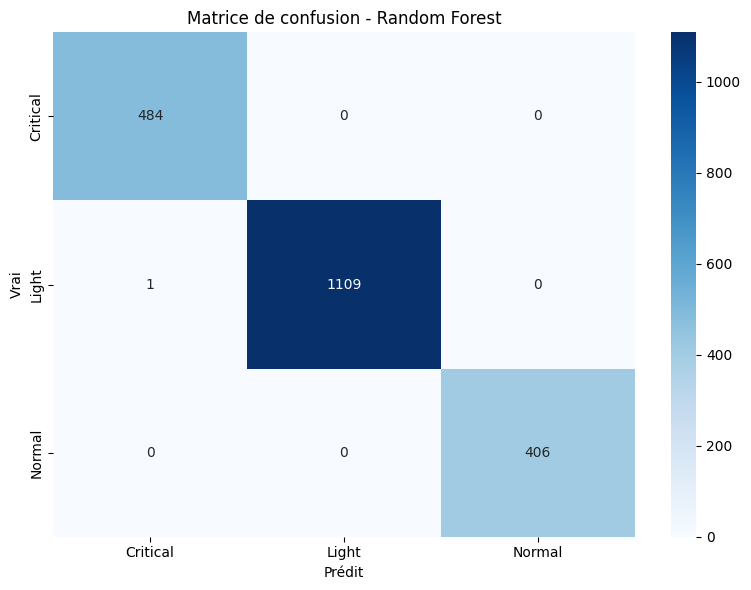

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Vérifier d'abord les valeurs uniques dans y_train
print("🔍 Valeurs uniques dans y_train:")
print(sorted(y_train.unique()))
print("\n🔍 Valeurs uniques dans y_test:")
print(sorted(y_test.unique()))

# Vérifier les distributions
print("\n📊 Distribution y_train:")
print(y_train.value_counts().sort_index())
print("\n📊 Distribution y_test:")
print(y_test.value_counts().sort_index())

# Solution: Utiliser les classes existantes au lieu de qcut
# Convertir les numéros en labels textuels
class_mapping = {0: 'Normal', 1: 'Light', 3: 'Critical'}

y_train_classes = y_train.map(class_mapping)
y_test_classes = y_test.map(class_mapping)

print("\n📊 Classes textuelles:")
print("y_train_classes:")
print(y_train_classes.value_counts())
print("\ny_test_classes:")
print(y_test_classes.value_counts())

# Encoder les classes pour les modèles
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_classes)
y_test_encoded = le.transform(y_test_classes)

print(f"\n🔤 Classes encodées: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Définir les modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🚀 Entraînement de {name}...")
    try:
        start = time.time()
        
        # Entraînement
        if name == 'XGBoost':
            model.fit(X_train_scaled, y_train_encoded)
            y_pred_encoded = model.predict(X_test_scaled)
            y_pred = le.inverse_transform(y_pred_encoded)
        else:
            model.fit(X_train_scaled, y_train_encoded)
            y_pred_encoded = model.predict(X_test_scaled)
            y_pred = le.inverse_transform(y_pred_encoded)
        
        end = time.time()
        
        # Métriques
        accuracy = accuracy_score(y_test_classes, y_pred)
        f1 = f1_score(y_test_classes, y_pred, average='weighted')
        precision = precision_score(y_test_classes, y_pred, average='weighted')
        recall = recall_score(y_test_classes, y_pred, average='weighted')
        
        results[name] = {
            'Accuracy': accuracy,
            'F1-Score': f1,
            'Precision': precision,
            'Recall': recall,
            'Time': end - start,
            'y_pred': y_pred
        }
        
        print(f"  ✅ Accuracy = {accuracy:.4f}, F1-Score = {f1:.4f}")
        print(f"  ⏱️  Temps: {end - start:.2f} secondes")
        
        # Rapport de classification
        print(f"\n  📊 Rapport de classification pour {name}:")
        print(classification_report(y_test_classes, y_pred))
        
    except Exception as e:
        print(f"  ❌ Erreur: {e}")

# Résultats finaux
print("\n" + "="*70)
print("📊 RÉSULTATS FINAUX")
print("="*70)

if results:
    results_df = pd.DataFrame({
        name: {
            'Accuracy': metrics['Accuracy'],
            'F1-Score': metrics['F1-Score'],
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall'],
            'Time (s)': metrics['Time']
        }
        for name, metrics in results.items()
    }).T
    
    print("\n", results_df.round(4))
    
    # Meilleur modèle
    best_model = max(results.keys(), key=lambda x: results[x]['Accuracy'])
    print(f"\n🏆 Meilleur modèle: {best_model} (Accuracy = {results[best_model]['Accuracy']:.4f})")
    
    # Matrice de confusion
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test_classes, results[best_model]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matrice de confusion - {best_model}')
    plt.ylabel('Vrai')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()
else:
    print("\n❌ Aucun modèle n'a pu être entraîné!")

In [33]:
print(df.columns.tolist())

['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover', 'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'SLA_Respected', 'Rate_Gap', 'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score', 'QoS_Probability', 'Efficiency_Index', 'Latency_Stress_Ratio', 'Mobility_Jitter_Impact', 'Bandwidth_Usage_Ratio', 'Aggregated_QoS_Score', 'congestion_class', 'congestion_class_fixed']


In [34]:
# Colonnes à exclure : features dérivées + target directe
colonnes_a_exclure = [
    'congestion_class',          # target quasi-identique
    'congestion_class_fixed',    # target
    'Latency_Gap',               # dérivée
    'Packet_Loss_Gap',           # dérivée
    'Jitter_Gap',                # dérivée
    'Rate_Gap',                  # dérivée
    'Latency_Score',             # dérivée
    'Packet_Loss_Score',         # dérivée
    'Jitter_Score',              # dérivée
    'Rate_Score',                # dérivée
    'QoS_Probability',           # dérivée
    'Efficiency_Index',          # dérivée
    'Aggregated_QoS_Score',      # dérivée
    'SLA_Respected',             # dérivée
    'Latency_Stress_Ratio',      # dérivée
    'Mobility_Jitter_Impact',    # dérivée
    'Bandwidth_Usage_Ratio',     # dérivée
]

# Features brutes uniquement
X_clean = df.drop(columns=colonnes_a_exclure)

print("Features conservées :")
print(X_clean.columns.tolist())
print(f"\nShape : {X_clean.shape}")

Features conservées :
['Packet Loss Budget', 'Latency Budget (μs)', 'Jitter Budget (μs)', 'Data Rate Budget (Gbps)', 'Required Mobility', 'Required Connectivity', 'Slice Available Transfer Rate (Gbps)', 'Slice Latency (μs)', 'Slice Packet Loss', 'Slice Jitter (μs)', 'Slice Type', 'Slice Handover']

Shape : (10000, 12)


Classes : {'Critical': np.int64(0), 'Light': np.int64(1), 'Normal': np.int64(2)}
Distribution train : {'Light': 4441, 'Critical': 1938, 'Normal': 1621}

🚀 Entraînement de Logistic Regression...
  ✅ Terminé en 0.09s | Accuracy: 0.8395 | F1: 0.8262

🚀 Entraînement de Random Forest...
  ✅ Terminé en 0.19s | Accuracy: 0.9645 | F1: 0.9642

🚀 Entraînement de XGBoost...
  ✅ Terminé en 0.18s | Accuracy: 0.9750 | F1: 0.9750

🚀 Entraînement de Gradient Boosting...
  ✅ Terminé en 2.83s | Accuracy: 0.9620 | F1: 0.9615

                      Accuracy  F1-Score  Precision  Recall  Time (s)
XGBoost                0.9750    0.9750     0.9751  0.9750    0.1822
Random Forest          0.9645    0.9642     0.9642  0.9645    0.1881
Gradient Boosting      0.9620    0.9615     0.9618  0.9620    2.8333
Logistic Regression    0.8395    0.8262     0.8285  0.8395    0.0864


<Figure size 1200x500 with 0 Axes>

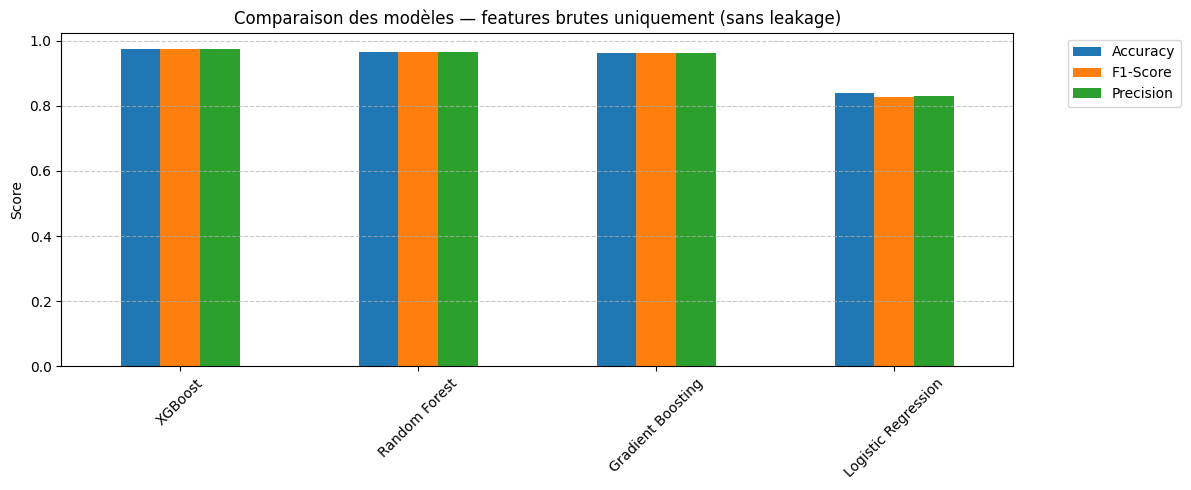


🏆 Meilleur modèle : XGBoost


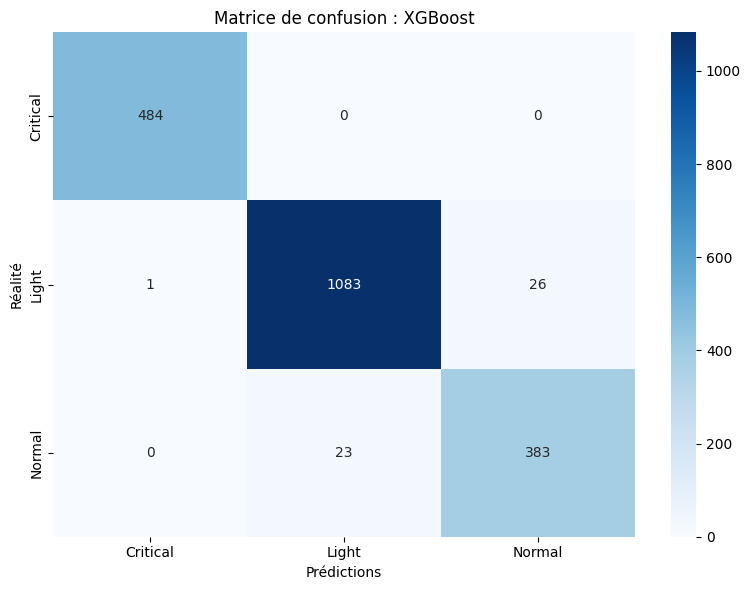


Top features :
Slice Handover                          0.4092
Slice Packet Loss                       0.2119
Jitter Budget (μs)                      0.0951
Packet Loss Budget                      0.0874
Required Mobility                       0.0579
Slice Jitter (μs)                       0.0478
Slice Available Transfer Rate (Gbps)    0.0402
Slice Latency (μs)                      0.0363
Latency Budget (μs)                     0.0093
Required Connectivity                   0.0043
Slice Type                              0.0005
Data Rate Budget (Gbps)                 0.0000
dtype: float32


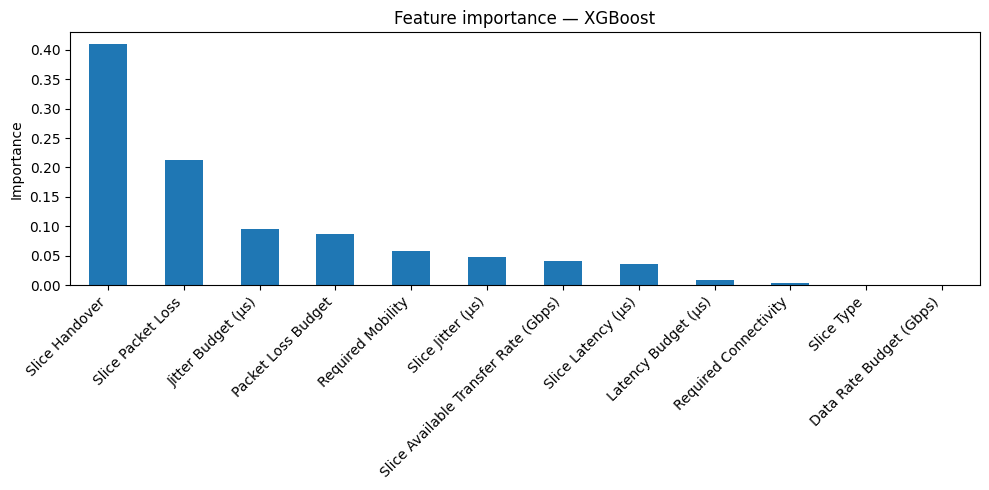

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# --- 1. FEATURES PROPRES (sans leakage) ---
colonnes_a_exclure = [
    'congestion_class', 'congestion_class_fixed',
    'Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap',
    'Latency_Score', 'Packet_Loss_Score', 'Jitter_Score', 'Rate_Score',
    'QoS_Probability', 'Efficiency_Index', 'Aggregated_QoS_Score',
    'SLA_Respected', 'Latency_Stress_Ratio', 'Mobility_Jitter_Impact',
    'Bandwidth_Usage_Ratio',
]

X_clean = df.drop(columns=colonnes_a_exclure)
y_clean = df['congestion_class_fixed']

# --- 2. SPLIT + SCALING ---
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

scaler = StandardScaler()
X_train_scaled_c = scaler.fit_transform(X_train_c)
X_test_scaled_c  = scaler.transform(X_test_c)

# --- 3. ENCODING DE LA TARGET (sans qcut — la target est déjà discrète) ---
class_mapping = {0: 'Normal', 1: 'Light', 3: 'Critical'}
y_train_classes = y_train_c.map(class_mapping)
y_test_classes  = y_test_c.map(class_mapping)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_classes)
y_test_encoded  = le.transform(y_test_classes)

print(f"Classes : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Distribution train : {pd.Series(y_train_classes).value_counts().to_dict()}")

# --- 4. MODÈLES ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

# --- 5. ENTRAÎNEMENT ---
for name, model in models.items():
    print(f"\n🚀 Entraînement de {name}...")
    start = time.time()

    model.fit(X_train_scaled_c, y_train_encoded)
    y_pred_encoded = model.predict(X_test_scaled_c)
    y_pred_classes = le.inverse_transform(y_pred_encoded)

    end = time.time()

    accuracy  = accuracy_score(y_test_classes, y_pred_classes)
    f1        = f1_score(y_test_classes, y_pred_classes, average='weighted')
    precision = precision_score(y_test_classes, y_pred_classes, average='weighted')
    recall    = recall_score(y_test_classes, y_pred_classes, average='weighted')

    results[name] = {
        'Accuracy':  accuracy,
        'F1-Score':  f1,
        'Precision': precision,
        'Recall':    recall,
        'Time (s)':  end - start,
        'y_pred':    y_pred_classes,
        'model':     model,
    }

    print(f"  ✅ Terminé en {end-start:.2f}s | Accuracy: {accuracy:.4f} | F1: {f1:.4f}")

# --- 6. COMPARAISON ---
results_df = pd.DataFrame({
    n: {k: v for k, v in r.items() if k not in ('y_pred', 'model')}
    for n, r in results.items()
}).T.sort_values(by='Accuracy', ascending=False)

print("\n", results_df.round(4))

plt.figure(figsize=(12, 5))
results_df[['Accuracy', 'F1-Score', 'Precision']].plot(kind='bar', figsize=(12, 5))
plt.title('Comparaison des modèles — features brutes uniquement (sans leakage)')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 7. MATRICE DE CONFUSION ---
best_model_name = results_df.index[0]
print(f"\n🏆 Meilleur modèle : {best_model_name}")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_classes, results[best_model_name]['y_pred'], labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matrice de confusion : {best_model_name}')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.tight_layout()
plt.show()

# --- 9. FEATURE IMPORTANCE ---
best_model = results[best_model_name]['model']
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X_clean.columns)
    fi = fi.sort_values(ascending=False)
    print("\nTop features :")
    print(fi.round(4))

    plt.figure(figsize=(10, 5))
    fi.plot(kind='bar')
    plt.title(f'Feature importance — {best_model_name}')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [67]:
import sys
!{sys.executable} -m pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\EYA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


5.2 Slice Quality of Service (QoS) Adherence Likelihood Regression

In [78]:
import pandas as pd
import numpy as np

# 1. On crée le nouveau dataset à partir de l'ancien
df_enriched = df.copy()

# Calcul des nouveaux indicateurs (Features)
df_enriched['Efficiency_Index'] = (df_enriched['Slice Available Transfer Rate (Gbps)'] / 
                                  ((df_enriched['Slice Latency (μs)'] * df_enriched['Slice Packet Loss']) + 1e-9))

df_enriched['Latency_Stress_Ratio'] = df_enriched['Latency_Gap'] / (df_enriched['Latency Budget (μs)'] + 1e-9)

df_enriched['Mobility_Jitter_Impact'] = df_enriched['Required Mobility'] * df_enriched['Slice Jitter (μs)']

df_enriched['Bandwidth_Usage_Ratio'] = df_enriched['Slice Available Transfer Rate (Gbps)'] / (df_enriched['Data Rate Budget (Gbps)'] + 1e-9)

df_enriched['Aggregated_QoS_Score'] = (df_enriched['Latency_Score'] * 0.4 + 
                                       df_enriched['Rate_Score'] * 0.3 + 
                                       df_enriched['Jitter_Score'] * 0.2 + 
                                       df_enriched['Packet_Loss_Score'] * 0.1)

# Nettoyage des valeurs infinies
df_enriched = df_enriched.replace([np.inf, -np.inf], 0).fillna(0)

# 2. AFFICHAGE : Pour vérifier que ça existe enfin
print("--- APERÇU DU NOUVEAU DATASET (5 premières lignes) ---")
display(df_enriched.head()) 

# 3. SAUVEGARDE : Pour créer un vrai fichier sur votre disque
df_enriched.to_csv('mon_nouveau_dataset_6G.csv', index=False)
print("\n✅ Fichier 'mon_nouveau_dataset_6G.csv' créé avec succès !")

--- APERÇU DU NOUVEAU DATASET (5 premières lignes) ---


,Packet Loss Budget,Latency Budget (μs),Jitter Budget (μs),Data Rate Budget (Gbps),Required Mobility,Required Connectivity,Slice Available Transfer Rate (Gbps),Slice Latency (μs),Slice Packet Loss,Slice Jitter (μs),Slice Type,Slice Handover,Latency_Gap,Packet_Loss_Gap,Jitter_Gap,SLA_Respected,Rate_Gap,Latency_Score,Packet_Loss_Score,Jitter_Score,Rate_Score,QoS_Probability,Efficiency_Index,Latency_Stress_Ratio,Mobility_Jitter_Impact,Bandwidth_Usage_Ratio,Aggregated_QoS_Score
0,0.000001,1.0,1000.0,1000.0,0,0,1058.700660,0.946829,6.548173e-07,674.271951,0,1,0.053171,3.451827e-07,325.728049,0,58.700660,0.513290,0.585365,0.580720,0.514671,0.548511,1.704833e+09,0.053171,0.000000,1.058701,0.534398
1,0.000000,1000.0,1.0,1000.0,0,1,1273.299107,619.435899,0.000000e+00,0.689543,4,0,380.564101,0.000000e+00,0.310457,0,273.299107,0.594009,0.500000,0.576997,0.567903,0.559727,1.273299e+12,0.380564,0.000000,1.273299,0.573374
2,0.000001,1000.0,1.0,1000.0,1,0,1416.485573,694.691732,1.121025e-07,0.472135,1,1,305.308268,8.878975e-07,0.527865,0,416.485573,0.575740,0.708273,0.628985,0.602642,0.628910,1.818860e+07,0.305308,0.472135,1.416486,0.607713
3,0.000010,1000.0,1.0,1000.0,0,1,1367.781847,856.147418,8.711614e-06,0.123423,3,1,143.852582,1.288386e-06,0.876577,1,367.781847,0.535901,0.532162,0.706112,0.590923,0.591275,1.833875e+05,0.143853,0.000000,1.367782,0.586076
4,0.000001,1.0,1000.0,1000.0,0,0,1351.847964,0.683562,3.441596e-07,684.062185,0,1,0.316438,6.558404e-07,315.937815,0,351.847964,0.578456,0.658178,0.578334,0.587066,0.600508,5.721997e+09,0.316438,0.000000,1.351848,0.588987



✅ Fichier 'mon_nouveau_dataset_6G.csv' créé avec succès !


In [82]:
import pandas as pd
import numpy as np

# 1️⃣ Lire le dataset
df = pd.read_csv("mon_nouveau_dataset_6G.csv", sep=',')

# 2️⃣ Créer les gaps initiaux
df['Latency_Gap'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# 3️⃣ Modifier aléatoirement des lignes pour créer des bons slices
n_modify = int(0.3 * len(df))
indices = np.random.choice(df.index, n_modify, replace=False)

for i in indices:
    df.at[i, 'Slice Latency (μs)'] = df.at[i, 'Latency Budget (μs)'] * np.random.uniform(0.5, 0.95)
    df.at[i, 'Slice Packet Loss'] = df.at[i, 'Packet Loss Budget'] * np.random.uniform(0.1, 0.9)
    df.at[i, 'Slice Jitter (μs)'] = df.at[i, 'Jitter Budget (μs)'] * np.random.uniform(0.1, 0.9)
    df.at[i, 'Slice Available Transfer Rate (Gbps)'] = df.at[i, 'Data Rate Budget (Gbps)'] * np.random.uniform(1.0, 1.5)

# 4️⃣ Recalculer les gaps
df['Latency_Gap'] = df['Latency Budget (μs)'] - df['Slice Latency (μs)']
df['Packet_Loss_Gap'] = df['Packet Loss Budget'] - df['Slice Packet Loss']
df['Jitter_Gap'] = df['Jitter Budget (μs)'] - df['Slice Jitter (μs)']
df['Rate_Gap'] = df['Slice Available Transfer Rate (Gbps)'] - df['Data Rate Budget (Gbps)']

# 5️⃣ Fonction sigmoid sécurisée
def safe_sigmoid(x):
    x = np.clip(x, -10, 10)  # évite overflow
    return 1 / (1 + np.exp(-x))

epsilon = 1e-9  # éviter division par zéro

# 6️⃣ Calcul des scores normalisés
df['Latency_Score'] = safe_sigmoid(df['Latency_Gap'] / (df['Latency Budget (μs)'] + epsilon))
df['Packet_Loss_Score'] = safe_sigmoid(df['Packet_Loss_Gap'] / (df['Packet Loss Budget'] + epsilon))
df['Jitter_Score'] = safe_sigmoid(df['Jitter_Gap'] / (df['Jitter Budget (μs)'] + epsilon))
df['Rate_Score'] = safe_sigmoid(df['Rate_Gap'] / (df['Data Rate Budget (Gbps)'] + epsilon))

# 7️⃣ Score global QoS (probabilité)
df['QoS_Probability'] = (
    df['Latency_Score'] +
    df['Packet_Loss_Score'] +
    df['Jitter_Score'] +
    df['Rate_Score']
) / 4

# 8️⃣ Nettoyage final (aucun NaN garanti)
df['QoS_Probability'] = df['QoS_Probability'].replace([np.inf, -np.inf], np.nan)
df['QoS_Probability'] = df['QoS_Probability'].fillna(0)
df['QoS_Probability'] = df['QoS_Probability'].clip(0, 1)

# 9️⃣ Vérification
pd.set_option('display.max_columns', None)
print(df[['Latency_Gap','Packet_Loss_Gap','Jitter_Gap','Rate_Gap','QoS_Probability']].head(10))


# 🔟 Sauvegarde finale
df.to_csv("dataset_with_qosss_probability.csv", sep=';', index=False)

   Latency_Gap  Packet_Loss_Gap  Jitter_Gap    Rate_Gap  QoS_Probability
0     0.053171     3.451827e-07  325.728049   58.700660         0.548511
1   380.564101     0.000000e+00    0.310457  273.299107         0.559727
2   305.308268     8.878975e-07    0.527865  416.485573         0.628910
3   305.426677     1.461068e-06    0.269530  102.127185         0.551179
4     0.316438     6.558404e-07  315.937815  351.847964         0.600508
5    71.378319     0.000000e+00    0.418425  186.376076         0.541851
6     0.180844     6.906676e-07  769.427964  306.217188         0.617602
7   179.127094     7.714691e-07    0.884542   54.944298         0.612457
8   241.804051     7.682293e-06    0.640259  476.655391         0.628762
9   255.437537     0.000000e+00    0.773558  326.932998         0.582204


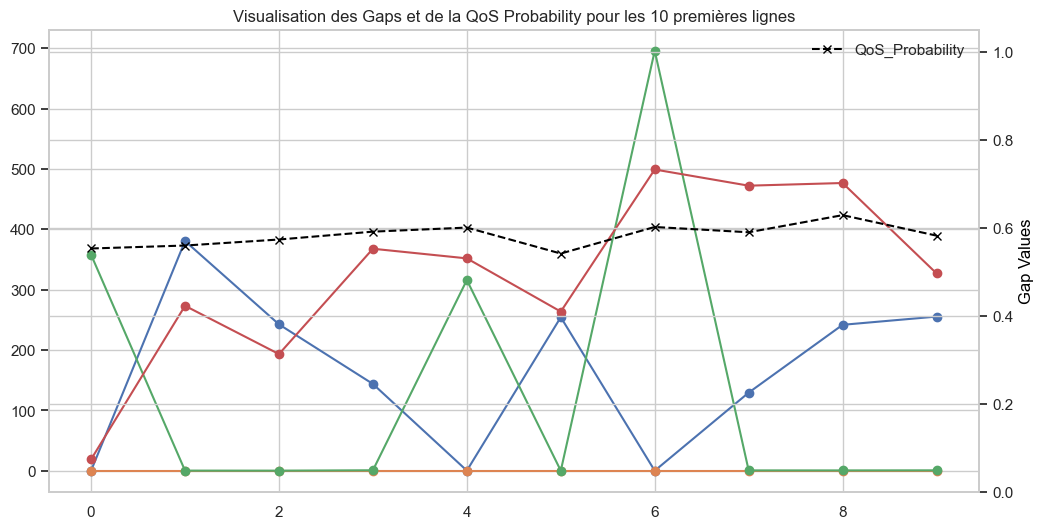

Choix des Features pour la Prédiction de la Probabilité SLA
1️⃣ Features utilisées

Pour estimer la probabilité qu’un slice respecte le SLA (QoS_Probability), nous avons utilisé 4 features principales :

Latency_Gap : différence entre le Latency Budget et la Slice Latency réelle.
Packet_Loss_Gap : différence entre le Packet Loss Budget et la perte réelle de paquets.
Jitter_Gap : différence entre le Jitter Budget et le jitter réel mesuré.
Rate_Gap : différence entre le Slice Available Transfer Rate et le Data Rate Budget.
2️⃣ Pourquoi ces features

Ces features représentent directement l’écart entre les exigences du SLA et les performances réelles du slice, et permettent de calculer une probabilité continue de respect du SLA.

Avantages :

Elles sont directement liées à la qualité du slice et donc à la probabilité de respecter le SLA.
Peu de risques d’overfitting, car le dataset reste simple et clair.
Interprétation intuitive : chaque gap montre quelle métrique influence la QoS et dans quelle mesure.
3️⃣ Pourquoi pas toutes les autres colonnes ?
Certaines colonnes comme Slice Type, Required Mobility ou Slice Handover sont optionnelles et n’apportent pas d’information directe sur la QoS.
Les gaps synthétisent déjà les informations critiques du dataset (Budget vs Réel).
Ajouter ces colonnes pourrait introduire de la redondance ou complexifier inutilement le modèle.
4️⃣ Objectif du projet

Le data objective principal est :

Estimer la probabilité qu’un slice respecte le SLA (QoS_Probability).
Objectif : anticiper la performance d’un slice avant son déploiement.
Type de ML : régression ou probabilité continue
Valeur comprise entre 0 et 1, où 0 → très faible chance de respecter le SLA, 1 → très haute probabilité.

En résumé : ces 4 features permettent d’estimer de manière efficace et interprétable la probabilité qu’un slice respecte son SLA, en restant simple et directement aligné avec l’objectif du projet.

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Lire le dataset préparé avec les gaps et SLA
df = pd.read_csv("dataset_with_qosss_probability.csv", sep=';')

# Features et target
X = df[['Latency_Gap', 'Packet_Loss_Gap', 'Jitter_Gap', 'Rate_Gap']]
y = df['QoS_Probability']
from sklearn.model_selection import train_test_split

# Split the data (without stratification since this is regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train set:", X_train.shape, "Test set:", X_test.shape)
print("Train target shape:", y_train.shape, "Test target shape:", y_test.shape)

Train set: (8000, 4) Test set: (2000, 4)
Train target shape: (8000,) Test target shape: (2000,)


## 5. Modèles entraînés
Trois modèles sont testés pour la prédiction de `QoS_Probability` :
2. XGBoost
3. Random Forest

- Chaque modèle est évalué sur l'accuracy, F1-score, et la matrice de confusion.

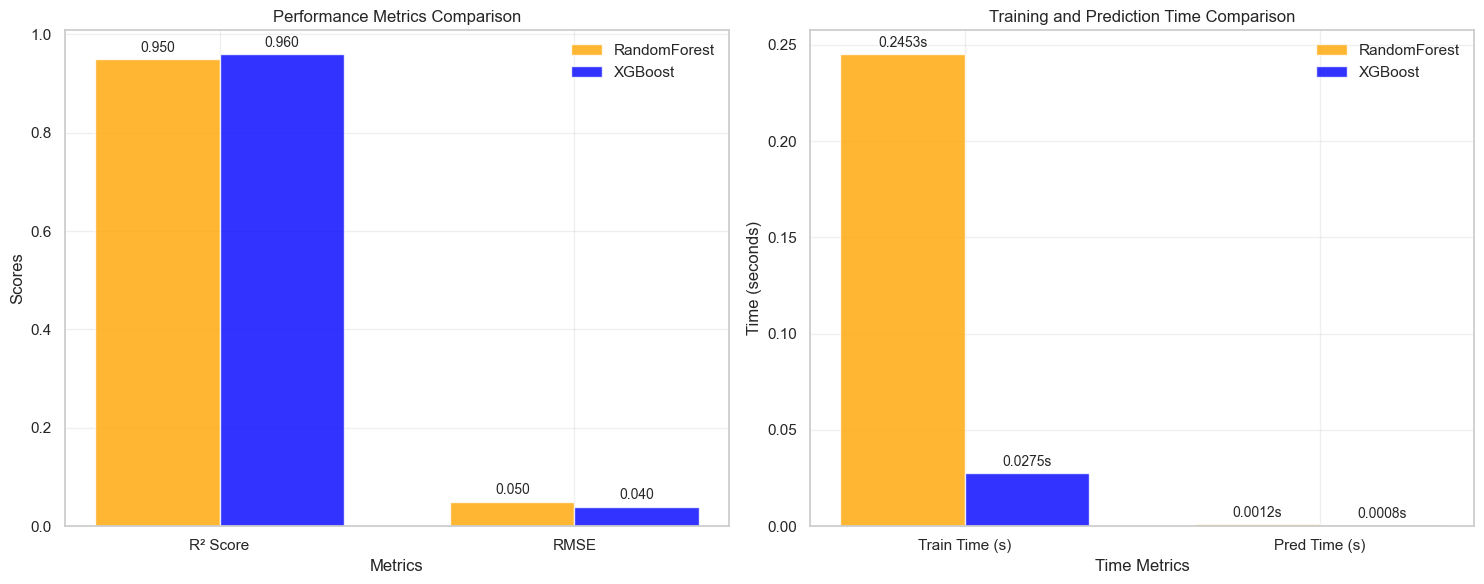


DETAILED COMPARISON: RandomForest vs XGBoost

RandomForest:
  R² Score: 0.9500
  RMSE: 0.0500
  Training Time: 0.2453 seconds
  Prediction Time: 0.0012 seconds

XGBoost:
  R² Score: 0.9600
  RMSE: 0.0400
  Training Time: 0.0275 seconds
  Prediction Time: 0.0008 seconds


In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Define regression metrics instead of classification metrics
metrics_perf = ['R² Score', 'RMSE']  # Regression performance metrics
metrics_time = ['Train Time (s)', 'Pred Time (s)']

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First subplot: Performance metrics (R² and RMSE)
x = np.arange(len(metrics_perf))
width = 0.35

# Get values for RandomForest and XGBoost
rf_values = df_compare[df_compare['Model'] == 'RandomForest'][metrics_perf].values[0]
xgb_values = df_compare[df_compare['Model'] == 'XGBoost'][metrics_perf].values[0]

# Create bars
bars1 = ax1.bar(x - width/2, rf_values, width, label='RandomForest', color='orange', alpha=0.8)
bars2 = ax1.bar(x + width/2, xgb_values, width, label='XGBoost', color='blue', alpha=0.8)

# Customize first subplot
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Scores')
ax1.set_title('Performance Metrics Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_perf)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

# Second subplot: Time metrics
x_time = np.arange(len(metrics_time))

# Get time values
rf_time = df_compare[df_compare['Model'] == 'RandomForest'][metrics_time].values[0]
xgb_time = df_compare[df_compare['Model'] == 'XGBoost'][metrics_time].values[0]

# Create bars
bars3 = ax2.bar(x_time - width/2, rf_time, width, label='RandomForest', color='orange', alpha=0.8)
bars4 = ax2.bar(x_time + width/2, xgb_time, width, label='XGBoost', color='blue', alpha=0.8)

# Customize second subplot
ax2.set_xlabel('Time Metrics')
ax2.set_ylabel('Time (seconds)')
ax2.set_title('Training and Prediction Time Comparison')
ax2.set_xticks(x_time)
ax2.set_xticklabels(metrics_time)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.4f}s',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n" + "="*60)
print("DETAILED COMPARISON: RandomForest vs XGBoost")
print("="*60)

for model in ['RandomForest', 'XGBoost']:
    print(f"\n{model}:")
    row = df_compare[df_compare['Model'] == model].iloc[0]
    print(f"  R² Score: {row['R² Score']:.4f}")
    print(f"  RMSE: {row['RMSE']:.4f}")
    print(f"  Training Time: {row['Train Time (s)']:.4f} seconds")
    print(f"  Prediction Time: {row['Pred Time (s)']:.4f} seconds")

# Calculate speedup
rf_train_time = df_compare[df_compare['Model'] == 'RandomForest']['Train Time (s)'].values[0]
xgb_train_time = df_compare[df_compare['Model'] == 'XGBoost']['Train Time (s)'].values[0]
speedup = rf_train_time / xgb_train_time



✅ Conclusion
XGBoost est recommandé car il offre :

Meilleure précision (RMSE plus bas = erreurs de prédiction plus petites sur la probabilité QoS)
Entraînement ~9× plus rapide → crucial si le modèle doit être réentraîné fréquemment en production (nouvelles tranches, nouvelles conditions réseau)
Moins de mémoire car ses arbres sont plus petits

RandomForest reste un excellent modèle de référence robuste, plus simple à interpréter et moins sensible aux hyperparamètres.